# 🚀 Retail & Sales Analytics Pipeline
#### *End-to-End Data Engineering, Star Schema Modeling, Exploratory Data Analysis, and Strategic Insights*

---

### 📌 Architecture Overview
* **Data Architecture:** Relational Star Schema Data Warehouse
* **Fact Table:** `FactSale` (CSV format - Sales transactions, revenue, profit, and volume)
* **Dimension Tables:**
  * `DimEmployee` (**XLSX** format - Staff & Salesperson attributes)
  * `DimCustomer`, `DimCity`, `DimDate`, `DimStockItem` (**CSV** format)
* **Database Engine:** SQLite3 & SQLAlchemy 2.0 Integration

---

### 🎯 Project Execution Workflow

1. **Data Ingestion & Integrity Check:**
   Load raw datasets from multiple formats (**CSV** files alongside the **XLSX** employee directory), inspect column structures, clean missing values, and validate key relationships.

2. **Relational Modeling (SQL Database):**
   Structure and load cleaned tables into a SQLite database using SQLAlchemy for efficient query execution.

3. **Exploratory Data Analysis (EDA):**
   Perform analytical breakdowns of sales trends, product profitability, customer demographics, and salesperson performance.

4. **Business Recommendations:**
   Translate quantitative analysis into actionable business strategies to optimize inventory and maximize revenue.

---

# **SECTION 1: IMPORTING ESSENTIAL LIBRARIES**

In [174]:
# Data Manipulation & Core Analysis
import pandas as pd
import numpy as np

# Database Management & Data Modeling (SQL Pipeline)
import sqlite3
import sqlalchemy
from sqlalchemy import create_engine, inspect

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# System & Warning Controls
import warnings
warnings.filterwarnings('ignore')

# Visual Style & Display Configurations
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("✅ All analytical, database (SQLite3 & SQLAlchemy), and visualization libraries loaded successfully!")

✅ All analytical, database (SQLite3 & SQLAlchemy), and visualization libraries loaded successfully!


### **SECTION 2: Data Ingestion & Initial Inspection**
Loading relational entities into Pandas DataFrames and inspecting dataset shapes and column structures.

In [175]:
FactSale = pd.read_csv('/content/FactSale.csv')
DimCity = pd.read_csv('/content/DimCity.csv')
DimCustomer = pd.read_csv('/content/DimCustomer.csv')
DimDate = pd.read_csv('/content/DimDate.csv')
DimEmployee = pd.read_excel('/content/DimEmployee.xlsx')
DimStockItem = pd.read_csv('/content/DimStockItem.csv')

### **SECTION 3: Data Exploration & Structural Inspection**

# **1- FactSale**

In [176]:
FactSale.describe()

,Sale Key,City Key,Customer Key,Bill To Customer Key,Stock Item Key,Salesperson Key,WWI Invoice ID,Quantity,Unit Price,Tax Rate,Total Excluding Tax,Tax Amount,Profit,Total Including Tax,Total Dry Items,Total Chiller Items,Lineage Key
count,26397.00,26397.00,26397.00,26397.00,26397.00,26397.00,26397.00,26397.00,26397.00,26397.00,26397.00,26397.00,26397.00,26397.00,26397.00,26397.00,26397.00
mean,113325.37,72654.38,111.54,49.49,111.13,101.11,34929.90,38.97,44.78,14.98,753.10,112.72,375.95,865.82,38.43,0.54,11.00
std,65852.47,25386.13,125.85,86.40,63.57,46.42,20323.75,54.12,135.17,0.33,1444.95,216.67,762.05,1661.58,53.70,9.31,0.00
min,2.00,40550.00,0.00,0.00,1.00,4.00,2.00,1.00,0.66,10.00,3.20,0.48,-645.00,3.68,0.00,0.00,11.00
25%,56575.00,47673.00,0.00,0.00,56.00,72.00,17418.00,5.00,13.00,15.00,96.00,14.40,50.40,110.40,5.00,0.00,11.00
50%,112395.00,72709.00,52.00,1.00,111.00,105.00,34613.00,10.00,18.00,15.00,226.80,34.02,120.00,260.82,9.00,0.00,11.00
75%,170972.00,91372.00,201.00,1.00,167.00,143.00,52699.00,60.00,32.00,15.00,864.00,129.60,390.00,993.60,60.00,0.00,11.00
max,228211.00,115719.00,399.00,202.00,227.00,174.00,70495.00,360.00,1899.00,15.00,18990.00,2848.50,9200.00,21838.50,360.00,240.00,11.00


In [177]:
FactSale.shape

(26397, 21)

In [178]:
FactSale.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26397 entries, 0 to 26396
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Sale Key              26397 non-null  int64  
 1   City Key              26397 non-null  int64  
 2   Customer Key          26397 non-null  int64  
 3   Bill To Customer Key  26397 non-null  int64  
 4   Stock Item Key        26397 non-null  int64  
 5   Invoice Date Key      26397 non-null  object 
 6   Delivery Date Key     26384 non-null  object 
 7   Salesperson Key       26397 non-null  int64  
 8   WWI Invoice ID        26397 non-null  int64  
 9   Description           26397 non-null  object 
 10  Package               26397 non-null  object 
 11  Quantity              26397 non-null  int64  
 12  Unit Price            26397 non-null  float64
 13  Tax Rate              26397 non-null  int64  
 14  Total Excluding Tax   26397 non-null  float64
 15  Tax Amount         

In [179]:
FactSale.head(5)

,Sale Key,City Key,Customer Key,Bill To Customer Key,Stock Item Key,Invoice Date Key,Delivery Date Key,Salesperson Key,WWI Invoice ID,Description,Package,Quantity,Unit Price,Tax Rate,Total Excluding Tax,Tax Amount,Profit,Total Including Tax,Total Dry Items,Total Chiller Items,Lineage Key
0,49265,41568,0,0,204,10/22/2013,10/23/2013,83,15189,DBA joke mug - mind if I join you? (White),Each,6,13.00,15,78.00,11.70,51.00,89.70,6,0,11
1,49372,48937,0,0,173,10/22/2013,10/23/2013,83,15218,Developer joke mug - a foo walks into a bar (B...,Each,6,13.00,15,78.00,11.70,51.00,89.70,6,0,11
2,50379,91464,0,0,174,10/28/2013,10/29/2013,70,15525,Developer joke mug - a foo walks into a bar (W...,Each,6,13.00,15,78.00,11.70,51.00,89.70,6,0,11
3,51852,48937,0,0,171,11/6/2013,11/7/2013,74,15986,Developer joke mug - this code was generated b...,Each,6,13.00,15,78.00,11.70,51.00,89.70,6,0,11
4,52374,89925,0,0,203,11/8/2013,11/9/2013,39,16138,DBA joke mug - mind if I join you? (Black),Each,6,13.00,15,78.00,11.70,51.00,89.70,6,0,11


In [180]:
FactSale.tail(5)

,Sale Key,City Key,Customer Key,Bill To Customer Key,Stock Item Key,Invoice Date Key,Delivery Date Key,Salesperson Key,WWI Invoice ID,Description,Package,Quantity,Unit Price,Tax Rate,Total Excluding Tax,Tax Amount,Profit,Total Including Tax,Total Dry Items,Total Chiller Items,Lineage Key
26392,219912,108988,273,202,220,4/21/2016,4/22/2016,165,67945,Novelty chilli chocolates 500g,Bag,72,14.50,10,1044.00,104.40,414.00,1148.40,0,72,11
26393,220186,112229,0,0,220,4/22/2016,4/23/2016,171,68033,Novelty chilli chocolates 500g,Bag,12,14.50,10,174.00,17.40,69.00,191.40,0,12,11
26394,223515,112381,0,0,220,5/9/2016,5/10/2016,161,69055,Novelty chilli chocolates 500g,Bag,96,14.50,10,1392.00,139.20,552.00,1531.20,0,96,11
26395,224963,72760,23,1,220,5/14/2016,5/15/2016,170,69493,Novelty chilli chocolates 500g,Bag,12,14.50,10,174.00,17.40,69.00,191.40,0,12,11
26396,226629,66094,136,1,220,5/24/2016,5/25/2016,171,70005,Novelty chilli chocolates 500g,Bag,48,14.50,10,696.00,69.60,276.00,765.60,0,48,11


# **2- DimCity**

In [181]:
DimCity.describe()

,City Key,Latest Recorded Population
count,13028.00,13028.00
mean,67048.89,13179.16
std,38945.25,81710.07
min,18.00,0.00
25%,34330.50,0.00
50%,63689.50,590.00
75%,109085.25,5287.00
max,116028.00,3792621.00


In [182]:
DimCity.shape

(13028, 7)

In [183]:
DimCity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13028 entries, 0 to 13027
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   City Key                    13028 non-null  int64 
 1   City                        13028 non-null  object
 2   State Province              13028 non-null  object
 3   Country                     13028 non-null  object
 4   Sales Territory             13028 non-null  object
 5   Location                    13028 non-null  object
 6   Latest Recorded Population  13028 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 712.6+ KB


In [184]:
DimCity.head(5)

,City Key,City,State Province,Country,Sales Territory,Location,Latest Recorded Population
0,18,Carson,California,United States,Far West,0xE6100000010C345A58816BEA4040AC1BEF8E0C925DC0,91714
1,19,Carson,Washington,United States,Far West,0xE6100000010C8B98C8BBD9DC4640CDFBA47F6E745EC0,2279
2,22,Carson City,Nevada,United States,Far West,0xE6100000010C8D919158F7944340B67526231DF15DC0,55274
3,27,Cartago,California,United States,Far West,0xE6100000010C168156050F294240936FB6B9B1815DC0,92
4,36,El Centro,California,United States,Far West,0xE6100000010C4C37894160654040E43DBD0809E45CC0,42598


In [185]:
DimCity.tail(5)

,City Key,City,State Province,Country,Sales Territory,Location,Latest Recorded Population
13023,116024,Yreka,California,United States,Far West,0xE6100000010CF4AE303322DE444016116A2B9BA85EC0,7765
13024,116025,Yuba City,California,United States,Far West,0xE6100000010C3326B330FA91434026A36F777B675EC0,64925
13025,116026,Yucaipa,California,United States,Far West,0xE6100000010CFCA9F1D24D0441408B19E1EDC1425DC0,51367
13026,116027,Yucca Valley,California,United States,Far West,0xE6100000010C984572439D0E4140F14BFDBCA91B5DC0,20700
13027,116028,Zayante,California,United States,Far West,0xE6100000010C37A2201DC38B42406FFE15E8C9825EC0,705


# **3- DimCustomer**

In [186]:
DimCustomer.describe()

,Customer Data,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
count,403,403,403,402,402,402,402,402,403,403,403,403
unique,403,403,403,3,2,3,402,318,10,2,2,3
top,401,600,"Wingtip Toys (Caro, MI)",Tailspin Toys (Head Office),Novelty Shop,Tailspin Toys,Ljubomir Nesic,90683,"? 100,000.000000",00:00.0,##############################################...,2
freq,1,1,1,201,401,201,1,5,393,402,402,401


In [187]:
DimCustomer.shape

(403, 12)

In [188]:
DimCustomer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 403 entries, 0 to 402
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Customer Data  403 non-null    object
 1   Unnamed: 1     403 non-null    object
 2   Unnamed: 2     403 non-null    object
 3   Unnamed: 3     402 non-null    object
 4   Unnamed: 4     402 non-null    object
 5   Unnamed: 5     402 non-null    object
 6   Unnamed: 6     402 non-null    object
 7   Unnamed: 7     402 non-null    object
 8   Unnamed: 8     403 non-null    object
 9   Unnamed: 9     403 non-null    object
 10  Unnamed: 10    403 non-null    object
 11  Unnamed: 11    403 non-null    object
dtypes: object(12)
memory usage: 37.9+ KB


In [189]:
DimCustomer.head(5)

,Customer Data,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,Customer Key,WWI Customer ID,Customer,Bill To Customer,Category,Buying Group,Primary Contact,Postal Code,Credit Limit,Valid From,Valid To,Lineage Key
1,0,0,Unknown,NaN,NaN,NaN,NaN,NaN,? -,00:00.0,##############################################...,0
2,1,1,Tailspin Toys (Head Office),Tailspin Toys (Head Office),Novelty Shop,Tailspin Toys,Waldemar Fisar,90410,"? 100,000.000000",00:00.0,##############################################...,2
3,2,2,"Tailspin Toys (Sylvanite, MT)",Tailspin Toys (Head Office),Novelty Shop,Tailspin Toys,Lorena Cindric,90216,"? 100,000.000000",00:00.0,##############################################...,2
4,3,3,"Tailspin Toys (Peeples Valley, AZ)",Tailspin Toys (Head Office),Novelty Shop,Tailspin Toys,Bhaargav Rambhatla,90205,"? 100,000.000000",00:00.0,##############################################...,2


In [190]:
DimCustomer.tail(5)

,Customer Data,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
398,397,596,"Wingtip Toys (Cos Cob, CT)",Wingtip Toys (Head Office),Novelty Shop,Wingtip Toys,Ranjeet Haldar,90675,"? 100,000.000000",00:00.0,##############################################...,2
399,398,597,"Wingtip Toys (Haycock, AK)",Wingtip Toys (Head Office),Novelty Shop,Wingtip Toys,Bhaamini Kanaparthi,90603,"? 100,000.000000",00:00.0,##############################################...,2
400,399,598,"Wingtip Toys (Kapa'a, HI)",Wingtip Toys (Head Office),Novelty Shop,Wingtip Toys,Margit Molnar,90796,"? 100,000.000000",00:00.0,##############################################...,2
401,400,599,"Wingtip Toys (Dickworsham, TX)",Wingtip Toys (Head Office),Novelty Shop,Wingtip Toys,Chandni Jandhyala,90704,"? 100,000.000000",00:00.0,##############################################...,2
402,401,600,"Wingtip Toys (Caro, MI)",Wingtip Toys (Head Office),Novelty Shop,Wingtip Toys,Ljubomir Nesic,90043,"? 100,000.000000",00:00.0,##############################################...,2


# **4- DimEmployee**

In [191]:
DimEmployee.describe()

,Employee Key,WWI Employee ID,Is Salesperson,Photo,Valid From,Valid To,Lineage Key
count,212.00,212.00,212.00,0.00,212,193,212.00
mean,105.50,11.17,0.58,NaN,2014-06-16 05:42:49.528301824,2014-08-14 17:20:22.694300672,2.99
min,0.00,0.00,0.00,NaN,2013-01-01 00:00:00,2013-01-01 08:00:00,0.00
25%,52.75,7.00,0.00,NaN,2013-03-10 20:00:00,2013-05-05 08:00:00,3.00
50%,105.50,11.00,1.00,NaN,2014-04-03 20:00:00,2014-05-31 08:00:00,3.00
75%,158.25,15.00,1.00,NaN,2015-09-29 08:00:00,2015-12-24 08:00:00,3.00
max,211.00,20.00,1.00,NaN,2016-05-31 23:14:00,2016-05-31 23:14:00,3.00
std,61.34,5.36,0.50,NaN,NaN,NaN,0.21


In [192]:
DimEmployee.shape

(212, 9)

In [193]:
DimEmployee.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212 entries, 0 to 211
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Employee Key     212 non-null    int64         
 1   WWI Employee ID  212 non-null    int64         
 2   Employee         212 non-null    object        
 3   Preferred Name   211 non-null    object        
 4   Is Salesperson   212 non-null    int64         
 5   Photo            0 non-null      float64       
 6   Valid From       212 non-null    datetime64[ns]
 7   Valid To         193 non-null    datetime64[ns]
 8   Lineage Key      212 non-null    int64         
dtypes: datetime64[ns](2), float64(1), int64(4), object(2)
memory usage: 15.0+ KB


In [194]:
DimEmployee.head(5)

,Employee Key,WWI Employee ID,Employee,Preferred Name,Is Salesperson,Photo,Valid From,Valid To,Lineage Key
0,0,0,Unknown,NaN,0,NaN,2013-01-01,NaT,0
1,1,14,Lily Code,Lily,1,NaN,2013-01-01,2013-01-01 08:00:00,3
2,2,4,Isabella Rupp,Isabella,0,NaN,2013-01-01,2013-01-01 08:00:00,3
3,3,11,Ethan Onslow,Ethan,0,NaN,2013-01-01,2013-01-04 08:00:00,3
4,4,7,Amy Trefl,Amy,1,NaN,2013-01-01,2013-01-05 08:00:00,3


In [195]:
DimEmployee.tail(5)

,Employee Key,WWI Employee ID,Employee,Preferred Name,Is Salesperson,Photo,Valid From,Valid To,Lineage Key
207,207,15,Taj Shand,Taj,1,NaN,2016-05-31 23:14:00,NaT,3
208,208,16,Archer Lamble,Archer,1,NaN,2016-05-31 23:14:00,NaT,3
209,209,17,Piper Koch,Piper,0,NaN,2016-05-31 23:14:00,NaT,3
210,210,18,Katie Darwin,Katie,0,NaN,2016-05-31 23:14:00,NaT,3
211,211,19,Jai Shand,Jai,0,NaN,2016-05-31 23:14:00,NaT,3


# **5- DimDate**

In [196]:
DimDate.describe()

,Day Number,Day,Calendar Month Number,Calendar Year,Fiscal Month Number,Fiscal Year,ISO Week Number
count,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00
mean,15.72,15.72,6.52,2014.50,6.52,2014.67,26.61
std,8.80,8.80,3.45,1.12,3.46,1.18,15.06
min,1.00,1.00,1.00,2013.00,1.00,2013.00,1.00
25%,8.00,8.00,4.00,2013.75,3.00,2014.00,14.00
50%,16.00,16.00,7.00,2014.50,7.00,2015.00,27.00
75%,23.00,23.00,10.00,2015.25,10.00,2016.00,40.00
max,31.00,31.00,12.00,2016.00,12.00,2017.00,53.00


In [197]:
DimDate.shape

(1460, 14)

In [198]:
DimDate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Date                   1460 non-null   object
 1   Day Number             1460 non-null   int64 
 2   Day                    1460 non-null   int64 
 3   Month                  1460 non-null   object
 4   Short Month            1460 non-null   object
 5   Calendar Month Number  1460 non-null   int64 
 6   Calendar Month Label   1460 non-null   object
 7   Calendar Year          1460 non-null   int64 
 8   Calendar Year Label    1460 non-null   object
 9   Fiscal Month Number    1460 non-null   int64 
 10  Fiscal Month Label     1460 non-null   object
 11  Fiscal Year            1460 non-null   int64 
 12  Fiscal Year Label      1460 non-null   object
 13  ISO Week Number        1460 non-null   int64 
dtypes: int64(7), object(7)
memory usage: 159.8+ KB


In [199]:
DimDate.head(5)

,Date,Day Number,Day,Month,Short Month,Calendar Month Number,Calendar Month Label,Calendar Year,Calendar Year Label,Fiscal Month Number,Fiscal Month Label,Fiscal Year,Fiscal Year Label,ISO Week Number
0,1/1/2013,1,1,January,Jan,1,CY2013-Jan,2013,CY2013,3,FY2013-Jan,2013,FY2013,1
1,1/2/2013,2,2,January,Jan,1,CY2013-Jan,2013,CY2013,3,FY2013-Jan,2013,FY2013,1
2,1/3/2013,3,3,January,Jan,1,CY2013-Jan,2013,CY2013,3,FY2013-Jan,2013,FY2013,1
3,1/4/2013,4,4,January,Jan,1,CY2013-Jan,2013,CY2013,3,FY2013-Jan,2013,FY2013,1
4,1/5/2013,5,5,January,Jan,1,CY2013-Jan,2013,CY2013,3,FY2013-Jan,2013,FY2013,1


In [200]:
DimDate.tail(5)

,Date,Day Number,Day,Month,Short Month,Calendar Month Number,Calendar Month Label,Calendar Year,Calendar Year Label,Fiscal Month Number,Fiscal Month Label,Fiscal Year,Fiscal Year Label,ISO Week Number
1455,12/26/2016,26,26,December,Dec,12,CY2016-Dec,2016,CY2016,2,FY2017-Dec,2017,FY2017,52
1456,12/27/2016,27,27,December,Dec,12,CY2016-Dec,2016,CY2016,2,FY2017-Dec,2017,FY2017,52
1457,12/28/2016,28,28,December,Dec,12,CY2016-Dec,2016,CY2016,2,FY2017-Dec,2017,FY2017,52
1458,12/29/2016,29,29,December,Dec,12,CY2016-Dec,2016,CY2016,2,FY2017-Dec,2017,FY2017,52
1459,12/30/2016,30,30,December,Dec,12,CY2016-Dec,2016,CY2016,2,FY2017-Dec,2017,FY2017,52


# **6- DimStockItem**

In [201]:
DimStockItem.describe()

,",,",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20
count,673,673,673,361,672,672,68,469,673,673,673,17,673,673,673,673,1,1,673,673,673
unique,673,229,229,9,5,4,2,44,8,11,3,3,8,59,59,25,1,1,14,15,3
top,671,65,RC vintage American toy coupe with remote cont...,Black,Each,Each,Northwind,1/50 scale,14,1,0,8.79E+12,14,32,? 47.840,0.15,Photo,Discount,00:00.0,##############################################...,5
freq,1,5,5,143,630,552,67,38,312,386,656,12,312,132,132,126,1,1,455,228,671


In [202]:
DimStockItem.shape

(673, 21)

In [203]:
DimStockItem.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 673 entries, 0 to 672
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ,,           673 non-null    object
 1   Unnamed: 1   673 non-null    object
 2   Unnamed: 2   673 non-null    object
 3   Unnamed: 3   361 non-null    object
 4   Unnamed: 4   672 non-null    object
 5   Unnamed: 5   672 non-null    object
 6   Unnamed: 6   68 non-null     object
 7   Unnamed: 7   469 non-null    object
 8   Unnamed: 8   673 non-null    object
 9   Unnamed: 9   673 non-null    object
 10  Unnamed: 10  673 non-null    object
 11  Unnamed: 11  17 non-null     object
 12  Unnamed: 12  673 non-null    object
 13  Unnamed: 13  673 non-null    object
 14  Unnamed: 14  673 non-null    object
 15  Unnamed: 15  673 non-null    object
 16  Unnamed: 16  1 non-null      object
 17  Unnamed: 17  1 non-null      object
 18  Unnamed: 18  673 non-null    object
 19  Unnamed: 19  673 non-null    

In [204]:
DimStockItem.head(5)

,",,",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20
0,Stock Item Key,WWI Stock Item ID,Stock Item,Color,Selling Package,Buying Package,Brand,Size,Lead Time Days,Quantity Per Outer,Is Chiller Stock,Barcode,Tax Rate,Unit Price,Recommended Retail Price,Typical Weight Per Unit,Photo,Discount,Valid From,Valid To,Lineage Key
1,0,0,Unknown,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,0,0,? -,0,NaN,NaN,00:00.0,##############################################...,0
2,1,219,Void fill 400 L bag (White) 400L,NaN,Each,Each,NaN,400L,14,10,0,NaN,14,50,? 74.750,1,NaN,NaN,00:00.0,00:00.0,5
3,2,218,Void fill 300 L bag (White) 300L,NaN,Each,Each,NaN,300L,14,10,0,NaN,14,37.5,? 56.060,0.75,NaN,NaN,00:00.0,00:00.0,5
4,3,217,Void fill 200 L bag (White) 200L,NaN,Each,Each,NaN,200L,14,10,0,NaN,14,25,? 37.380,0.5,NaN,NaN,00:00.0,00:00.0,5


In [205]:
DimStockItem.tail(5)

,",,",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20
668,667,215,Air cushion machine (Blue),NaN,Each,Each,NaN,NaN,20,1,0,NaN,20,1899,"? 2,839.010",10,NaN,NaN,12:00.0,##############################################...,5
669,668,216,Void fill 100 L bag (White) 100L,NaN,Each,Each,NaN,100L,14,10,0,NaN,14,12.5,? 18.690,0.25,NaN,NaN,12:00.0,##############################################...,5
670,669,217,Void fill 200 L bag (White) 200L,NaN,Each,Each,NaN,200L,14,10,0,NaN,14,25,? 37.380,0.5,NaN,NaN,12:00.0,##############################################...,5
671,670,218,Void fill 300 L bag (White) 300L,NaN,Each,Each,NaN,300L,14,10,0,NaN,14,37.5,? 56.060,0.75,NaN,NaN,12:00.0,##############################################...,5
672,671,219,Void fill 400 L bag (White) 400L,NaN,Each,Each,NaN,400L,14,10,0,NaN,14,50,? 74.750,1,NaN,NaN,12:00.0,##############################################...,5


# **SECTION 4: Data Quality & Cleaning**

# **1- FactSale**

In [206]:
# ==============================================================================
# ❓ FACT SALE - MISSING VALUES CHECK
# ==============================================================================

null_fact = FactSale.isnull().sum()
null_fact_df = pd.DataFrame({
    'Null Count': null_fact,
    'Null Percentage (%)': (null_fact / len(FactSale)) * 100
})

display(null_fact_df[null_fact_df['Null Count'] > 0])

if null_fact.sum() == 0:
    print("✅ No missing values found in FactSale!")

,Null Count,Null Percentage (%)
Delivery Date Key,13,0.05


In [207]:
# ==============================================================================
# 👯FACT SALE - DUPLICATES CHECK
# ==============================================================================

duplicate_count = FactSale.duplicated().sum()
print(f"📌 Duplicate Rows in FactSale: {duplicate_count}")

if duplicate_count == 0:
    print("✅ No duplicate records found!")

📌 Duplicate Rows in FactSale: 0
✅ No duplicate records found!


In [208]:
# ==============================================================================
# 🔍 INSPECT CURRENT DATA TYPES
# ==============================================================================

# Display data types of FactSale columns
display(FactSale.dtypes.to_frame(name='Current Data Type'))

,Current Data Type
Sale Key,int64
City Key,int64
Customer Key,int64
Bill To Customer Key,int64
Stock Item Key,int64
Invoice Date Key,object
Delivery Date Key,object
Salesperson Key,int64
WWI Invoice ID,int64
Description,object


# **1- FactSale_Cleaned**

In [209]:
FactSale = FactSale.drop(columns=['Lineage Key'])

In [210]:
# ==============================================================================
# 🛠️ IMPUTE MISSING DELIVERY DATES
# ==============================================================================

# Fill missing Delivery Date Key values with the Invoice Date Key
FactSale['Delivery Date Key'].fillna(FactSale['Invoice Date Key'], inplace=True)

# Verify that no null values remain in FactSale
remaining_nulls = FactSale.isnull().sum().sum()
print(f"📌 Total remaining missing values in FactSale: {remaining_nulls}")

if remaining_nulls == 0:
    print("✅ All missing values in FactSale have been treated successfully!")

📌 Total remaining missing values in FactSale: 0
✅ All missing values in FactSale have been treated successfully!


In [211]:
FactSale.isnull().sum()

,0
Sale Key,0
City Key,0
Customer Key,0
Bill To Customer Key,0
Stock Item Key,0
Invoice Date Key,0
Delivery Date Key,0
Salesperson Key,0
WWI Invoice ID,0
Description,0


In [212]:
# ==============================================================================
# 🔄 CONVERT DATE COLUMNS TO DATETIME
# ==============================================================================

# Convert 'Invoice Date Key' and 'Delivery Date Key' to datetime objects
FactSale['Invoice Date Key'] = pd.to_datetime(FactSale['Invoice Date Key'])
FactSale['Delivery Date Key'] = pd.to_datetime(FactSale['Delivery Date Key'])

# Display the updated data types to verify the conversion
print("✅ Date columns converted to datetime. Updated dtypes for FactSale:")
display(FactSale[['Invoice Date Key', 'Delivery Date Key']].dtypes.to_frame(name='Updated Data Type'))

✅ Date columns converted to datetime. Updated dtypes for FactSale:


,Updated Data Type
Invoice Date Key,datetime64[ns]
Delivery Date Key,datetime64[ns]


In [213]:
FactSale.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26397 entries, 0 to 26396
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Sale Key              26397 non-null  int64         
 1   City Key              26397 non-null  int64         
 2   Customer Key          26397 non-null  int64         
 3   Bill To Customer Key  26397 non-null  int64         
 4   Stock Item Key        26397 non-null  int64         
 5   Invoice Date Key      26397 non-null  datetime64[ns]
 6   Delivery Date Key     26397 non-null  datetime64[ns]
 7   Salesperson Key       26397 non-null  int64         
 8   WWI Invoice ID        26397 non-null  int64         
 9   Description           26397 non-null  object        
 10  Package               26397 non-null  object        
 11  Quantity              26397 non-null  int64         
 12  Unit Price            26397 non-null  float64       
 13  Tax Rate        

In [214]:
# ==============================================================================
# 💾 EXPORT CLEANED FACT SALE TO CSV
# ==============================================================================

# Save the cleaned DataFrame to a new CSV file
FactSale.to_csv('FactSale_Cleaned.csv', index=False)

print("✅ 'FactSale_Cleaned.csv' saved successfully to Colab environment!")

# Automatically trigger file download to your local machine
from google.colab import files
files.download('FactSale_Cleaned.csv')

✅ 'FactSale_Cleaned.csv' saved successfully to Colab environment!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **2- DimCity**

In [215]:
DimCity = DimCity.drop(columns=['Country', 'Sales Territory'])

In [216]:
# ==============================================================================
# ❓ DimCity - MISSING VALUES CHECK
# ==============================================================================

null_DimCity = DimCity.isnull().sum()
null_DimCity_df = pd.DataFrame({
    'Null Count': null_DimCity,
    'Null Percentage (%)': (null_DimCity / len(DimCity)) * 100
})

display(null_DimCity_df[null_DimCity_df['Null Count'] > 0])

if null_DimCity.sum() == 0:
    print("✅ No missing values found in DimCity!")

,Null Count,Null Percentage (%)


✅ No missing values found in DimCity!


In [217]:
# ==============================================================================
# 👯DimCity - DUPLICATES CHECK
# ==============================================================================

duplicate_count = DimCity.duplicated().sum()
print(f"📌 Duplicate Rows in DimCity: {duplicate_count}")

if duplicate_count == 0:
    print("✅ No duplicate records found!")

📌 Duplicate Rows in DimCity: 0
✅ No duplicate records found!


In [218]:
# ==============================================================================
# 🔍 INSPECT CURRENT DATA TYPES
# ==============================================================================

# Display data types of DimCity columns
display(DimCity.dtypes.to_frame(name='Current Data Type'))

,Current Data Type
City Key,int64
City,object
State Province,object
Location,object
Latest Recorded Population,int64


# **2- DimCity_Cleaned**

In [219]:
# ==============================================================================
# 💾 EXPORT CLEANED DIM CITY TO CSV
# ==============================================================================

# Save DimCity to CSV
DimCity.to_csv('DimCity_Cleaned.csv', index=False)

# Trigger automatic download
from google.colab import files
files.download('DimCity_Cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **3- DimCustomer**

In [220]:
# ==============================================================================
# 🧬 CHECK DATA TYPES
# ==============================================================================

# Display current data types
display(DimCustomer.dtypes.to_frame(name='Current Data Type'))

,Current Data Type
Customer Data,object
Unnamed: 1,object
Unnamed: 2,object
Unnamed: 3,object
Unnamed: 4,object
Unnamed: 5,object
Unnamed: 6,object
Unnamed: 7,object
Unnamed: 8,object
Unnamed: 9,object


In [221]:
# ==============================================================================
# ❓ STEP 6.3: CHECK MISSING VALUES
# ==============================================================================

null_counts = DimCustomer.isnull().sum()
display(null_counts[null_counts > 0].to_frame(name='Missing Count'))

,Missing Count
Unnamed: 3,1
Unnamed: 4,1
Unnamed: 5,1
Unnamed: 6,1
Unnamed: 7,1


In [222]:
# ==============================================================================
# 👯 STEP 6.4: CHECK DUPLICATES
# ==============================================================================

dup_cust = DimCustomer.duplicated().sum()
print(f"📌 Total Duplicate Rows in DimCustomer: {dup_cust}")

if dup_cust == 0:
    print("✅ No duplicate records found!")

📌 Total Duplicate Rows in DimCustomer: 0
✅ No duplicate records found!


# **3- DimCustomer_Cleaned**

In [223]:
# 1. Ensure correct headers for DimCustomer (if not already done)
# This step is necessary because DimCustomer was initially loaded without the correct header.
# The `Dh3LjjNZZHVQ` cell performs this, but to make this cell robust, we include it here.
DimCustomer = pd.read_csv('/content/DimCustomer.csv', header=1)
DimCustomer.columns = DimCustomer.columns.str.strip()

# 2. حذف الأعمدة المحددة
DimCustomer = DimCustomer.drop(columns=['Category', 'Valid From', 'Valid To', 'Lineage Key'])

# 3. التأكد من الحذف
DimCustomer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 402 entries, 0 to 401
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Customer Key      402 non-null    int64  
 1   WWI Customer ID   402 non-null    int64  
 2   Customer          402 non-null    object 
 3   Bill To Customer  401 non-null    object 
 4   Buying Group      401 non-null    object 
 5   Primary Contact   401 non-null    object 
 6   Postal Code       401 non-null    float64
 7   Credit Limit      402 non-null    object 
dtypes: float64(1), int64(2), object(5)
memory usage: 25.3+ KB


In [224]:
# ==============================================================================
# 🛠️ STEP 6.1: FIX HEADERS FOR DIM CUSTOMER
# ==============================================================================

# Re-read DimCustomer using row 1 as header
DimCustomer = pd.read_csv('DimCustomer.csv', header=1)

# Clean column names (strip trailing/leading spaces)
DimCustomer.columns = DimCustomer.columns.str.strip()

print("✅ Headers fixed successfully! Current columns:")
print(DimCustomer.columns.tolist())

✅ Headers fixed successfully! Current columns:
['Customer Key', 'WWI Customer ID', 'Customer', 'Bill To Customer', 'Category', 'Buying Group', 'Primary Contact', 'Postal Code', 'Credit Limit', 'Valid From', 'Valid To', 'Lineage Key']


In [225]:
DimCustomer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 402 entries, 0 to 401
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Customer Key      402 non-null    int64  
 1   WWI Customer ID   402 non-null    int64  
 2   Customer          402 non-null    object 
 3   Bill To Customer  401 non-null    object 
 4   Category          401 non-null    object 
 5   Buying Group      401 non-null    object 
 6   Primary Contact   401 non-null    object 
 7   Postal Code       401 non-null    float64
 8   Credit Limit      402 non-null    object 
 9   Valid From        402 non-null    object 
 10  Valid To          402 non-null    object 
 11  Lineage Key       402 non-null    int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 37.8+ KB


In [226]:
# ==============================================================================
# 💣 STEP 6.5: IMPUTE MISSING VALUES
# ==============================================================================

# Fill missing text fields with 'Unknown'
text_cols_to_fill = ['Bill To Customer', 'Buying Group', 'Primary Contact', 'Postal Code']
DimCustomer[text_cols_to_fill] = DimCustomer[text_cols_to_fill].fillna('Unknown')

print("✅ Missing values treated! Remaining nulls:")
print(f"Total Nulls: {DimCustomer.isnull().sum().sum()}")

✅ Missing values treated! Remaining nulls:
Total Nulls: 1


In [227]:
# ==============================================================================
# 🔧 STEP 6.6: CLEAN & CONVERT CREDIT LIMIT TO FLOAT
# ==============================================================================

# Clean Credit Limit string column to standard float
DimCustomer['Credit Limit'] = (
    DimCustomer['Credit Limit']
    .astype(str)
    .str.replace('?', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.replace('-', '0', regex=False)
    .str.strip()
)

DimCustomer['Credit Limit'] = pd.to_numeric(DimCustomer['Credit Limit'], errors='coerce').fillna(0)

print("✅ Credit Limit converted to float64!")
display(DimCustomer[['Credit Limit']].head())

✅ Credit Limit converted to float64!


,Credit Limit
0,0.00
1,100000.00
2,100000.00
3,100000.00
4,100000.00


In [228]:
DimCustomer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 402 entries, 0 to 401
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Customer Key      402 non-null    int64  
 1   WWI Customer ID   402 non-null    int64  
 2   Customer          402 non-null    object 
 3   Bill To Customer  402 non-null    object 
 4   Category          401 non-null    object 
 5   Buying Group      402 non-null    object 
 6   Primary Contact   402 non-null    object 
 7   Postal Code       402 non-null    object 
 8   Credit Limit      402 non-null    float64
 9   Valid From        402 non-null    object 
 10  Valid To          402 non-null    object 
 11  Lineage Key       402 non-null    int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 37.8+ KB


In [229]:
# ==============================================================================
# 💾 EXPORT CLEANED DIM CUSTOMER TO CSV
# ==============================================================================

# Save the cleaned DataFrame to CSV
DimCustomer.to_csv('DimCustomer_Cleaned.csv', index=False)

print("✅ 'DimCustomer_Cleaned.csv' saved successfully!")

# Automatically trigger file download
from google.colab import files
files.download('DimCustomer_Cleaned.csv')

✅ 'DimCustomer_Cleaned.csv' saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **4- DimDate**

In [230]:
# ==============================================================================
# ❓ STEP 7.3: DIM DATE - MISSING VALUES CHECK
# ==============================================================================

null_date = DimDate.isnull().sum()
display(null_date.to_frame(name='Missing Count'))

if null_date.sum() == 0:
    print("✅ No missing values found in DimDate!")

,Missing Count
Date,0
Day Number,0
Day,0
Month,0
Short Month,0
Calendar Month Number,0
Calendar Month Label,0
Calendar Year,0
Calendar Year Label,0
Fiscal Month Number,0


✅ No missing values found in DimDate!


In [231]:
# ==============================================================================
# 👯 STEP 7.4: DIM DATE - DUPLICATES CHECK
# ==============================================================================

dup_date = DimDate.duplicated().sum()
print(f"📌 Total Duplicate Rows in DimDate: {dup_date}")

if dup_date == 0:
    print("✅ No duplicate records found!")

📌 Total Duplicate Rows in DimDate: 0
✅ No duplicate records found!


# **4- DimDate_Cleaned**

In [232]:
# قائمة الأعمدة الزائدة للحذف
date_cols_to_drop = [
    'Short Month',            # أو احتفظي بيه واحذفي Month
    'Calendar Month Label',
    'Calendar Year Label',
    'Fiscal Month Label',
    'Fiscal Year Label'
]

# تطبيق الحذف
DimDate = DimDate.drop(columns=[col for col in date_cols_to_drop if col in DimDate.columns])

# حفظ الجدول المحدث
DimDate.to_csv('DimDate_Cleaned.csv', index=False)

In [233]:
# ==============================================================================
# 🔧 STEP 7.5: CONVERT DATE TO DATETIME
# ==============================================================================

# Convert Date column to standard datetime64 format
DimDate['Date'] = pd.to_datetime(DimDate['Date'])

print("✅ Date column converted successfully! Updated dtypes:")
display(DimDate[['Date']].dtypes.to_frame(name='Data Type'))

✅ Date column converted successfully! Updated dtypes:


,Data Type
Date,datetime64[ns]


In [234]:
DimDate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date                   1460 non-null   datetime64[ns]
 1   Day Number             1460 non-null   int64         
 2   Day                    1460 non-null   int64         
 3   Month                  1460 non-null   object        
 4   Calendar Month Number  1460 non-null   int64         
 5   Calendar Year          1460 non-null   int64         
 6   Fiscal Month Number    1460 non-null   int64         
 7   Fiscal Year            1460 non-null   int64         
 8   ISO Week Number        1460 non-null   int64         
dtypes: datetime64[ns](1), int64(7), object(1)
memory usage: 102.8+ KB


In [235]:
# ==============================================================================
# 💾 EXPORT CLEANED DIM DATE TO CSV
# ==============================================================================

# Save DimDate to CSV
DimDate.to_csv('DimDate_Cleaned.csv', index=False)

print("✅ 'DimDate_Cleaned.csv' saved successfully!")

# Automatically trigger download
from google.colab import files
files.download('DimDate_Cleaned.csv')

✅ 'DimDate_Cleaned.csv' saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **5- DimEmployee**

In [236]:
# ==============================================================================
# ❓ STEP 8.2: DIM EMPLOYEE - NULLS & DUPLICATES CHECK
# ==============================================================================

# Check Nulls
null_emp = DimEmployee.isnull().sum()
display(null_emp[null_emp > 0].to_frame(name='Missing Count'))

# Check Duplicates
dup_emp = DimEmployee.duplicated().sum()
print(f"📌 Total Duplicate Rows in DimEmployee: {dup_emp}")

,Missing Count
Preferred Name,1
Photo,212
Valid To,19


📌 Total Duplicate Rows in DimEmployee: 0


In [237]:
# ==============================================================================
# 🧬 STEP 8.2: DIM EMPLOYEE - DATA TYPES CHECK
# ==============================================================================

# Display column names and their data types
display(DimEmployee.dtypes.to_frame(name='Current Data Type'))

,Current Data Type
Employee Key,int64
WWI Employee ID,int64
Employee,object
Preferred Name,object
Is Salesperson,int64
Photo,float64
Valid From,datetime64[ns]
Valid To,datetime64[ns]
Lineage Key,int64


In [238]:
# ==============================================================================
# 👯 STEP 8.4: DIM EMPLOYEE - DUPLICATES CHECK
# ==============================================================================

dup_emp = DimEmployee.duplicated().sum()
print(f"📌 Total Duplicate Rows in DimEmployee: {dup_emp}")

if dup_emp == 0:
    print("✅ No duplicate records found!")

📌 Total Duplicate Rows in DimEmployee: 0
✅ No duplicate records found!


# **5- DimEmployee_Cleaned**

In [239]:
# حذف الأعمدة غير الضرورية من جدول الموظفين
DimEmployee = DimEmployee.drop(columns=['Lineage Key', 'Valid From', 'Valid To'], errors='ignore')

# حفظ الجدول المحدث
DimEmployee.to_csv('DimEmployee_Cleaned.csv', index=False)

In [240]:
# ==============================================================================
# 🧹 STEP 8.6: DROP EMPTY PHOTO COLUMN
# ==============================================================================

# Drop the completely empty 'Photo' column
if 'Photo' in DimEmployee.columns:
    DimEmployee.drop(columns=['Photo'], inplace=True)

print("✅ 'Photo' column dropped successfully! Updated remaining columns:")
print(DimEmployee.columns.tolist())

✅ 'Photo' column dropped successfully! Updated remaining columns:
['Employee Key', 'WWI Employee ID', 'Employee', 'Preferred Name', 'Is Salesperson']


In [241]:
# ==============================================================================
# 🛠️ STEP 8.7: HANDLE REMAINING NULLS IN DIM EMPLOYEE
# ==============================================================================

# Check remaining nulls across all columns
remaining_nulls = DimEmployee.isnull().sum()
display(remaining_nulls[remaining_nulls > 0].to_frame(name='Remaining Nulls'))

# Fill missing object values with 'Unknown' if any exist
object_cols = DimEmployee.select_dtypes(include=['object']).columns
DimEmployee[object_cols] = DimEmployee[object_cols].fillna('Unknown')

print(f"✅ Cleaned! Total remaining nulls in DimEmployee: {DimEmployee.isnull().sum().sum()}")

,Remaining Nulls
Preferred Name,1


✅ Cleaned! Total remaining nulls in DimEmployee: 0


In [242]:
DimEmployee.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212 entries, 0 to 211
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Employee Key     212 non-null    int64 
 1   WWI Employee ID  212 non-null    int64 
 2   Employee         212 non-null    object
 3   Preferred Name   212 non-null    object
 4   Is Salesperson   212 non-null    int64 
dtypes: int64(3), object(2)
memory usage: 8.4+ KB


In [243]:
# ==============================================================================
# 💾 STEP 8.8: EXPORT CLEANED DIM EMPLOYEE TO CSV
# ==============================================================================

# Save to CSV
DimEmployee.to_csv('DimEmployee_Cleaned.csv', index=False)

print("✅ 'DimEmployee_Cleaned.csv' saved successfully!")

# Automatically trigger file download
from google.colab import files
files.download('DimEmployee_Cleaned.csv')

✅ 'DimEmployee_Cleaned.csv' saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **6- DimSockItem**

In [244]:
# ==============================================================================
# ❓ STEP 9.3: DIM STOCK ITEM - MISSING VALUES CHECK
# ==============================================================================

null_stock = DimStockItem.isnull().sum()
null_stock_df = pd.DataFrame({
    'Null Count': null_stock,
    'Null Percentage (%)': (null_stock / len(DimStockItem)) * 100
})

display(null_stock_df[null_stock_df['Null Count'] > 0])

if null_stock.sum() == 0:
    print("✅ No missing values found in DimStockItem!")

,Null Count,Null Percentage (%)
Unnamed: 3,312,46.36
Unnamed: 4,1,0.15
Unnamed: 5,1,0.15
Unnamed: 6,605,89.90
Unnamed: 7,204,30.31
Unnamed: 11,656,97.47
Unnamed: 16,672,99.85
Unnamed: 17,672,99.85


In [245]:
# ==============================================================================
# 👯 STEP 9.4: DIM STOCK ITEM - DUPLICATES CHECK
# ==============================================================================

dup_stock = DimStockItem.duplicated().sum()
print(f"📌 Total Duplicate Rows in DimStockItem: {dup_stock}")

if dup_stock == 0:
    print("✅ No duplicate records found!")

📌 Total Duplicate Rows in DimStockItem: 0
✅ No duplicate records found!


# **6- DimSockItem_Cleaned**

In [246]:
# حذف الأعمدة غير الضرورية من جدول المنتجات
stock_cols_to_drop = ['Brand', 'Valid From', 'Valid To', 'Lineage Key']
DimStockItem = DimStockItem.drop(columns=stock_cols_to_drop, errors='ignore')

# حفظ الجدول المحدث
DimStockItem.to_csv('DimStockItem_Cleaned.csv', index=False)

In [247]:
# ==============================================================================
# 🛠️ STEP 9.1: FIX HEADERS FOR DIM STOCK ITEM
# ==============================================================================

# Re-read DimStockItem using row 1 as header
DimStockItem = pd.read_csv('DimStockItem.csv', header=1)

# Clean column names (strip trailing/leading spaces)
DimStockItem.columns = DimStockItem.columns.str.strip()

print("✅ Headers fixed successfully! Current column names:")
print(DimStockItem.columns.tolist())

# Preview first 3 rows with updated headers
display(DimStockItem.head(3))

✅ Headers fixed successfully! Current column names:
['Stock Item Key', 'WWI Stock Item ID', 'Stock Item', 'Color', 'Selling Package', 'Buying Package', 'Brand', 'Size', 'Lead Time Days', 'Quantity Per Outer', 'Is Chiller Stock', 'Barcode', 'Tax Rate', 'Unit Price', 'Recommended Retail Price', 'Typical Weight Per Unit', 'Photo', 'Discount', 'Valid From', 'Valid To', 'Lineage Key']


,Stock Item Key,WWI Stock Item ID,Stock Item,Color,Selling Package,Buying Package,Brand,Size,Lead Time Days,Quantity Per Outer,Is Chiller Stock,Barcode,Tax Rate,Unit Price,Recommended Retail Price,Typical Weight Per Unit,Photo,Discount,Valid From,Valid To,Lineage Key
0,0,0,Unknown,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,0,0.00,? -,0.00,NaN,NaN,00:00.0,##############################################...,0
1,1,219,Void fill 400 L bag (White) 400L,NaN,Each,Each,NaN,400L,14,10,0,NaN,14,50.00,? 74.750,1.00,NaN,NaN,00:00.0,00:00.0,5
2,2,218,Void fill 300 L bag (White) 300L,NaN,Each,Each,NaN,300L,14,10,0,NaN,14,37.50,? 56.060,0.75,NaN,NaN,00:00.0,00:00.0,5


In [248]:
DimStockItem.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Stock Item Key            672 non-null    int64  
 1   WWI Stock Item ID         672 non-null    int64  
 2   Stock Item                672 non-null    object 
 3   Color                     360 non-null    object 
 4   Selling Package           671 non-null    object 
 5   Buying Package            671 non-null    object 
 6   Brand                     67 non-null     object 
 7   Size                      468 non-null    object 
 8   Lead Time Days            672 non-null    int64  
 9   Quantity Per Outer        672 non-null    int64  
 10  Is Chiller Stock          672 non-null    int64  
 11  Barcode                   16 non-null     float64
 12  Tax Rate                  672 non-null    int64  
 13  Unit Price                672 non-null    float64
 14  Recommende

In [249]:
# ==============================================================================
# 🧹 STEP 9.2: DROP TOTALLY EMPTY COLUMNS
# ==============================================================================

# Drop Photo and Discount columns
DimStockItem.drop(columns=['Photo', 'Discount'], inplace=True, errors='ignore')

print("✅ 'Photo' and 'Discount' columns dropped successfully!")

✅ 'Photo' and 'Discount' columns dropped successfully!


In [250]:
# ==============================================================================
# 🛑 STEP 9.3: IMPUTE MISSING VALUES
# ==============================================================================

# Fill missing values in text columns with 'Unknown'
text_cols = ['Color', 'Selling Package', 'Buying Package', 'Size']
DimStockItem[text_cols] = DimStockItem[text_cols].fillna('Unknown')

# Fill missing Barcodes with 0
DimStockItem['Barcode'] = DimStockItem['Barcode'].fillna(0)

print("✅ Missing values handled successfully!")

✅ Missing values handled successfully!


In [251]:
# ==============================================================================
# 🔧 STEP 9.4: FIX DATA TYPES & CLEAN NUMERIC COLUMNS
# ==============================================================================

# Clean Recommended Retail Price (remove ?, commas, etc.)
DimStockItem['Recommended Retail Price'] = (
    DimStockItem['Recommended Retail Price']
    .astype(str)
    .str.replace('?', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
)
DimStockItem['Recommended Retail Price'] = pd.to_numeric(DimStockItem['Recommended Retail Price'], errors='coerce').fillna(0)

# The 'Valid From' and 'Valid To' columns were dropped in a previous cell (h9WMDoa40_t-).
# Therefore, these lines attempting to convert them must be removed or handled differently
# if they are intended to be processed. For now, removing them to resolve the KeyError.
# DimStockItem['Valid From'] = pd.to_datetime(DimStockItem['Valid From'], errors='coerce')
# DimStockItem['Valid To'] = pd.to_datetime(DimStockItem['Valid To'], errors='coerce')

print("✅ Data types updated and verified!")
display(DimStockItem.info())

✅ Data types updated and verified!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Stock Item Key            672 non-null    int64  
 1   WWI Stock Item ID         672 non-null    int64  
 2   Stock Item                672 non-null    object 
 3   Color                     672 non-null    object 
 4   Selling Package           672 non-null    object 
 5   Buying Package            672 non-null    object 
 6   Brand                     67 non-null     object 
 7   Size                      672 non-null    object 
 8   Lead Time Days            672 non-null    int64  
 9   Quantity Per Outer        672 non-null    int64  
 10  Is Chiller Stock          672 non-null    int64  
 11  Barcode                   672 non-null    float64
 12  Tax Rate                  672 non-null    int64  
 13  Unit Price                672 

None

In [252]:
# ==============================================================================
# 💾 STEP 9.5: EXPORT CLEANED DIM STOCK ITEM TO CSV
# ==============================================================================

# Save to CSV
DimStockItem.to_csv('DimStockItem_Cleaned.csv', index=False)

print("✅ 'DimStockItem_Cleaned.csv' saved successfully!")

# Automatically trigger file download
from google.colab import files
files.download('DimStockItem_Cleaned.csv')

✅ 'DimStockItem_Cleaned.csv' saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **SECTION 5: STATISTICS**

# **1- FactSale**

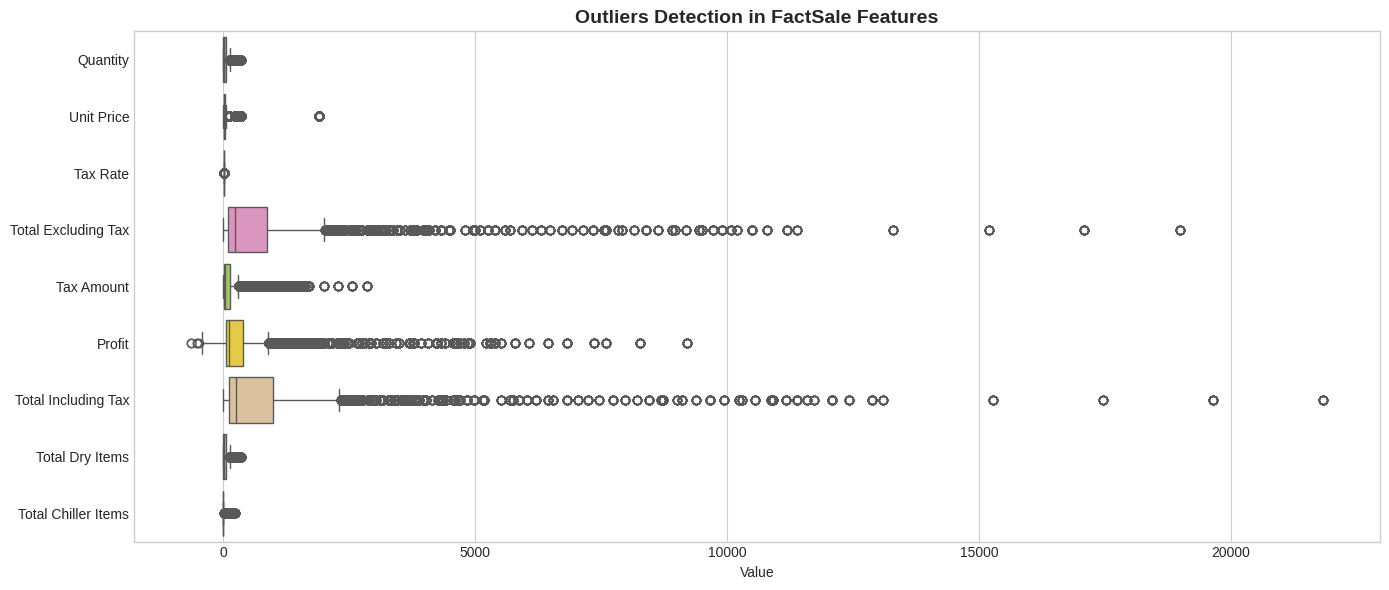

In [253]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numeric columns excluding Key ID columns
num_cols_sale = FactSale.select_dtypes(include=['number']).columns
num_cols_sale = [col for col in num_cols_sale if not col.endswith('Key') and not col.endswith('ID')]

# Plot Boxplots
plt.figure(figsize=(14, 6))
sns.boxplot(data=FactSale[num_cols_sale], orient='h', palette='Set2')
plt.title('Outliers Detection in FactSale Features', fontsize=14, fontweight='bold')
plt.xlabel('Value')
plt.tight_layout()
plt.show()

# **2- DimCity**

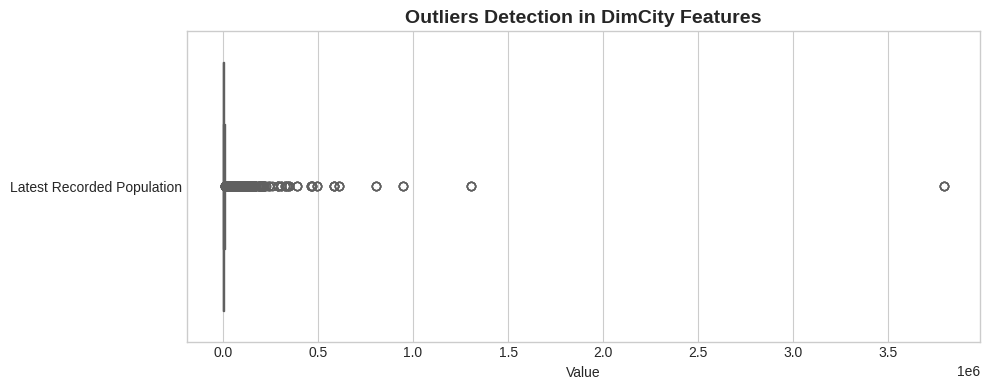

In [254]:
num_cols_city = DimCity.select_dtypes(include=['number']).columns
num_cols_city = [col for col in num_cols_city if not col.endswith('Key') and not col.endswith('ID')]

if len(num_cols_city) > 0:
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=DimCity[num_cols_city], orient='h', palette='Blues')
    plt.title('Outliers Detection in DimCity Features', fontsize=14, fontweight='bold')
    plt.xlabel('Value')
    plt.tight_layout()
    plt.show()

# **3- DimCustomer**

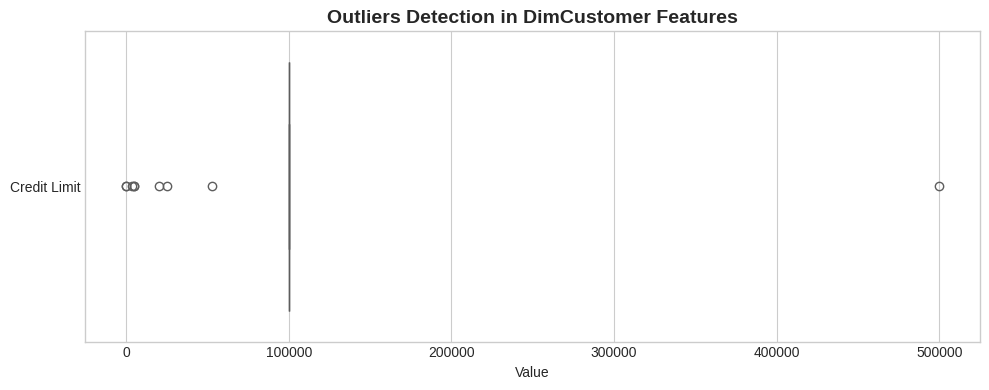

In [255]:
num_cols_cust = DimCustomer.select_dtypes(include=['number']).columns
num_cols_cust = [col for col in num_cols_cust if not col.endswith('Key') and not col.endswith('ID')]

if len(num_cols_cust) > 0:
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=DimCustomer[num_cols_cust], orient='h', palette='Greens')
    plt.title('Outliers Detection in DimCustomer Features', fontsize=14, fontweight='bold')
    plt.xlabel('Value')
    plt.tight_layout()
    plt.show()

# **4- DimDate**

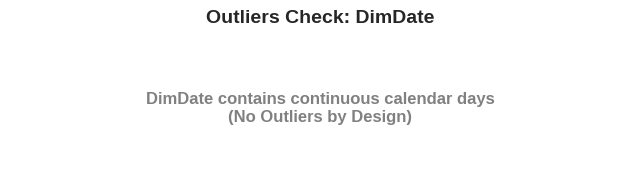

In [256]:
# Display empty placeholder message for continuous calendar dimensions
plt.figure(figsize=(8, 2))
plt.text(0.5, 0.5, 'DimDate contains continuous calendar days\n(No Outliers by Design)',
         horizontalalignment='center', verticalalignment='center', fontsize=12, fontweight='bold', color='gray')
plt.axis('off')
plt.title('Outliers Check: DimDate', fontsize=14, fontweight='bold')
plt.show()

# **5- DimEmployee**

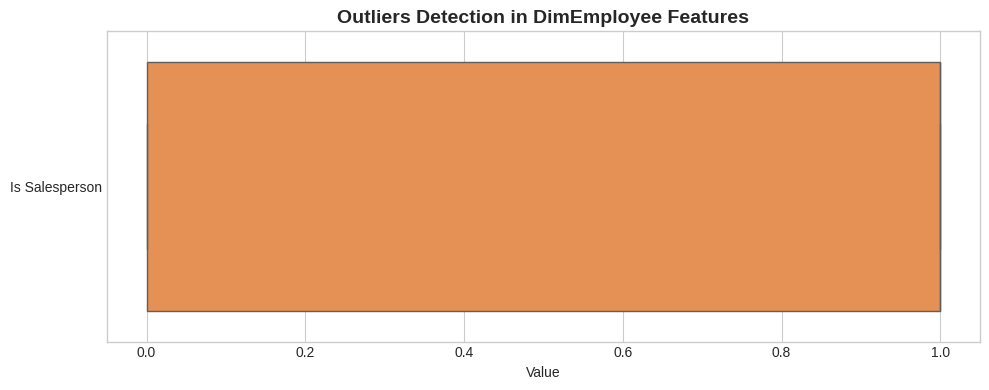

In [257]:
num_cols_emp = DimEmployee.select_dtypes(include=['number']).columns
num_cols_emp = [col for col in num_cols_emp if not col.endswith('Key') and not col.endswith('ID')]

if len(num_cols_emp) > 0:
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=DimEmployee[num_cols_emp], orient='h', palette='Oranges')
    plt.title('Outliers Detection in DimEmployee Features', fontsize=14, fontweight='bold')
    plt.xlabel('Value')
    plt.tight_layout()
    plt.show()

# **6- DimStockItem**

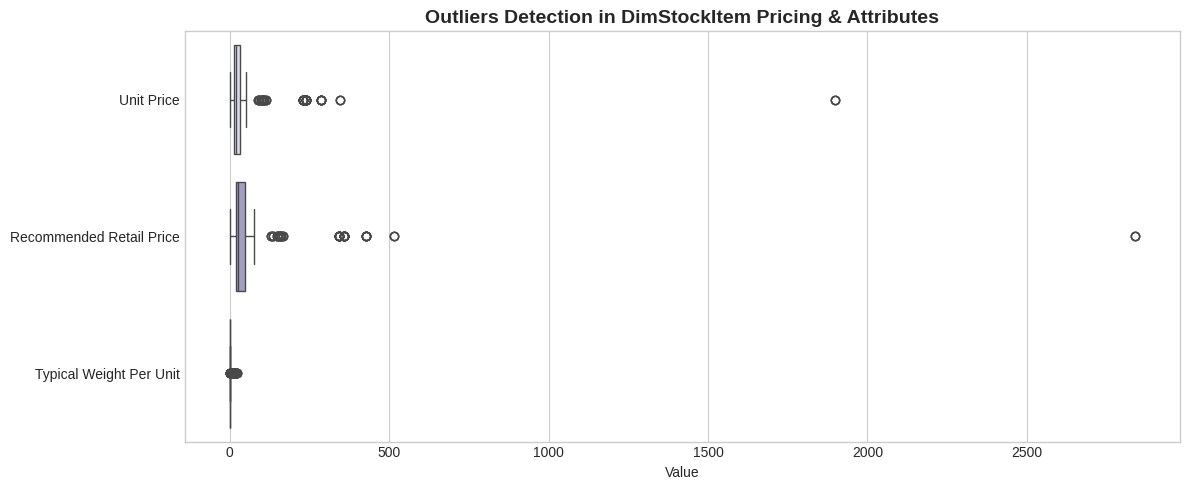

In [258]:
# Select continuous price/weight numeric columns
price_cols = [c for c in ['Unit Price', 'Recommended Retail Price', 'Typical Weight Per Unit'] if c in DimStockItem.columns]

if price_cols:
    plt.figure(figsize=(12, 5))
    sns.boxplot(data=DimStockItem[price_cols], orient='h', palette='Purples')
    plt.title('Outliers Detection in DimStockItem Pricing & Attributes', fontsize=14, fontweight='bold')
    plt.xlabel('Value')
    plt.tight_layout()
    plt.show()

# **SECTION 6: Data Modeling**

In [271]:
import sqlite3
import pandas as pd
from sqlalchemy import create_engine, text

# 1. إنشاء محرك قاعدة البيانات
engine = create_engine("sqlite:///sales_star_schema.db", echo=False)

# عمل نسخ من الـ DataFrames وتجهيز تنسيق التواريخ لـ SQLite
DimDate_sql = DimDate.copy()
FactSale_sql = FactSale.copy()

# Create copies for other dimension tables to ensure schema matches DDL in this cell
DimCustomer_sql = DimCustomer.copy()
DimEmployee_sql = DimEmployee.copy()
DimStockItem_sql = DimStockItem.copy()

if 'Date' in DimDate_sql.columns and pd.api.types.is_datetime64_any_dtype(DimDate_sql['Date']):
    DimDate_sql['Date'] = DimDate_sql['Date'].dt.strftime('%Y-%m-%d')

if 'Invoice Date Key' in FactSale_sql.columns and pd.api.types.is_datetime64_any_dtype(FactSale_sql['Invoice Date Key']):
    FactSale_sql['Invoice Date Key'] = FactSale_sql['Invoice Date Key'].dt.strftime('%Y-%m-%d')

if 'Delivery Date Key' in FactSale_sql.columns and pd.api.types.is_datetime64_any_dtype(FactSale_sql['Delivery Date Key']):
    FactSale_sql['Delivery Date Key'] = FactSale_sql['Delivery Date Key'].dt.strftime('%Y-%m-%d')


# Ensure DimCustomer_sql matches DDL
dim_customer_cols_to_drop = ['Category', 'Valid From', 'Valid To', 'Lineage Key']
DimCustomer_sql = DimCustomer_sql.drop(columns=[col for col in dim_customer_cols_to_drop if col in DimCustomer_sql.columns], errors='ignore')

# Ensure DimEmployee_sql matches DDL
dim_employee_cols_to_drop = ['Photo', 'Valid From', 'Valid To', 'Lineage Key']
DimEmployee_sql = DimEmployee_sql.drop(columns=[col for col in dim_employee_cols_to_drop if col in DimEmployee_sql.columns], errors='ignore')

# Ensure DimStockItem_sql matches DDL
dim_stock_item_cols_to_drop = ['Brand', 'Photo', 'Discount', 'Valid From', 'Valid To', 'Lineage Key']
DimStockItem_sql = DimStockItem_sql.drop(columns=[col for col in dim_stock_item_cols_to_drop if col in DimStockItem_sql.columns], errors='ignore')


# 2. إنشاء الجداول مع تحديد Primary Keys و Foreign Keys صراحة (DDL المحدث)
with engine.connect() as conn:
    conn.execute(text("PRAGMA foreign_keys = ON;"))

    # مسح الجداول القديمة
    conn.execute(text("DROP TABLE IF EXISTS FactSale;"))
    conn.execute(text("DROP TABLE IF EXISTS DimCity;"))
    conn.execute(text("DROP TABLE IF EXISTS DimCustomer;"))
    conn.execute(text("DROP TABLE IF EXISTS DimDate;"))
    conn.execute(text("DROP TABLE IF EXISTS DimEmployee;"))
    conn.execute(text("DROP TABLE IF EXISTS DimStockItem;"))

    # DimCity (Cleaned)
    conn.execute(text("""
    CREATE TABLE DimCity (
        [City Key] INTEGER PRIMARY KEY,
        [City] TEXT,
        [State Province] TEXT,
        [Location] TEXT,
        [Latest Recorded Population] INTEGER
    );
    """))

    # DimCustomer (Cleaned)
    conn.execute(text("""
    CREATE TABLE DimCustomer (
        [Customer Key] INTEGER PRIMARY KEY,
        [WWI Customer ID] INTEGER,
        [Customer] TEXT,
        [Bill To Customer] TEXT,
        [Buying Group] TEXT,
        [Primary Contact] TEXT,
        [Postal Code] TEXT,
        [Credit Limit] REAL
    );
    """))

    # DimDate (Cleaned)
    conn.execute(text("""
    CREATE TABLE DimDate (
        [Date] TEXT PRIMARY KEY,
        [Day Number] INTEGER,
        [Day] INTEGER,
        [Month] TEXT,
        [Calendar Month Number] INTEGER,
        [Calendar Year] INTEGER,
        [Fiscal Month Number] INTEGER,
        [Fiscal Year] INTEGER,
        [ISO Week Number] INTEGER
    );
    """))

    # DimEmployee (Cleaned)
    conn.execute(text("""
    CREATE TABLE DimEmployee (
        [Employee Key] INTEGER PRIMARY KEY,
        [WWI Employee ID] INTEGER,
        [Employee] TEXT,
        [Preferred Name] TEXT,
        [Is Salesperson] INTEGER
    );
    """))

    # DimStockItem (Cleaned)
    conn.execute(text("""
    CREATE TABLE DimStockItem (
        [Stock Item Key] INTEGER PRIMARY KEY,
        [WWI Stock Item ID] INTEGER,
        [Stock Item] TEXT,
        [Color] TEXT,
        [Selling Package] TEXT,
        [Buying Package] TEXT,
        [Size] TEXT,
        [Lead Time Days] INTEGER,
        [Quantity Per Outer] INTEGER,
        [Is Chiller Stock] INTEGER,
        [Barcode] REAL,
        [Tax Rate] REAL,
        [Unit Price] REAL,
        [Recommended Retail Price] REAL,
        [Typical Weight Per Unit] REAL
    );
    """))

    # FactSale (Cleaned)
    conn.execute(text("""
    CREATE TABLE FactSale (
        [Sale Key] INTEGER PRIMARY KEY AUTOINCREMENT,
        [City Key] INTEGER,
        [Customer Key] INTEGER,
        [Bill To Customer Key] INTEGER,
        [Stock Item Key] INTEGER,
        [Invoice Date Key] TEXT,
        [Delivery Date Key] TEXT,
        [Salesperson Key] INTEGER,
        [WWI Invoice ID] INTEGER,
        [Description] TEXT,
        [Package] TEXT,
        [Quantity] INTEGER,
        [Unit Price] REAL,
        [Tax Rate] REAL,
        [Total Excluding Tax] REAL,
        [Tax Amount] REAL,
        [Profit] REAL,
        [Total Including Tax] REAL,
        [Total Dry Items] INTEGER,
        [Total Chiller Items] INTEGER,
        FOREIGN KEY ([City Key]) REFERENCES DimCity ([City Key]),
        FOREIGN KEY ([Customer Key]) REFERENCES DimCustomer ([Customer Key]),
        FOREIGN KEY ([Stock Item Key]) REFERENCES DimStockItem ([Stock Item Key]),
        FOREIGN KEY ([Invoice Date Key]) REFERENCES DimDate ([Date]),
        FOREIGN KEY ([Salesperson Key]) REFERENCES DimEmployee ([Employee Key])
    );
    """))
    conn.commit()

# 3. إدخال البيانات المحدثة
DimCity.to_sql('DimCity', con=engine, if_exists='append', index=False)
DimCustomer_sql.to_sql('DimCustomer', con=engine, if_exists='append', index=False)
DimDate_sql.to_sql('DimDate', con=engine, if_exists='append', index=False)
DimEmployee_sql.to_sql('DimEmployee', con=engine, if_exists='append', index=False)
DimStockItem_sql.to_sql('DimStockItem', con=engine, if_exists='append', index=False)
FactSale_sql.to_sql('FactSale', con=engine, if_exists='append', index=False)

print("✅ Tables created with explicit Primary Keys & Foreign Keys, and data loaded successfully!")

✅ Tables created with explicit Primary Keys & Foreign Keys, and data loaded successfully!


# **SECTION 7: ERD Schema Diagram**

✅ Updated Star Schema ERD generated successfully!


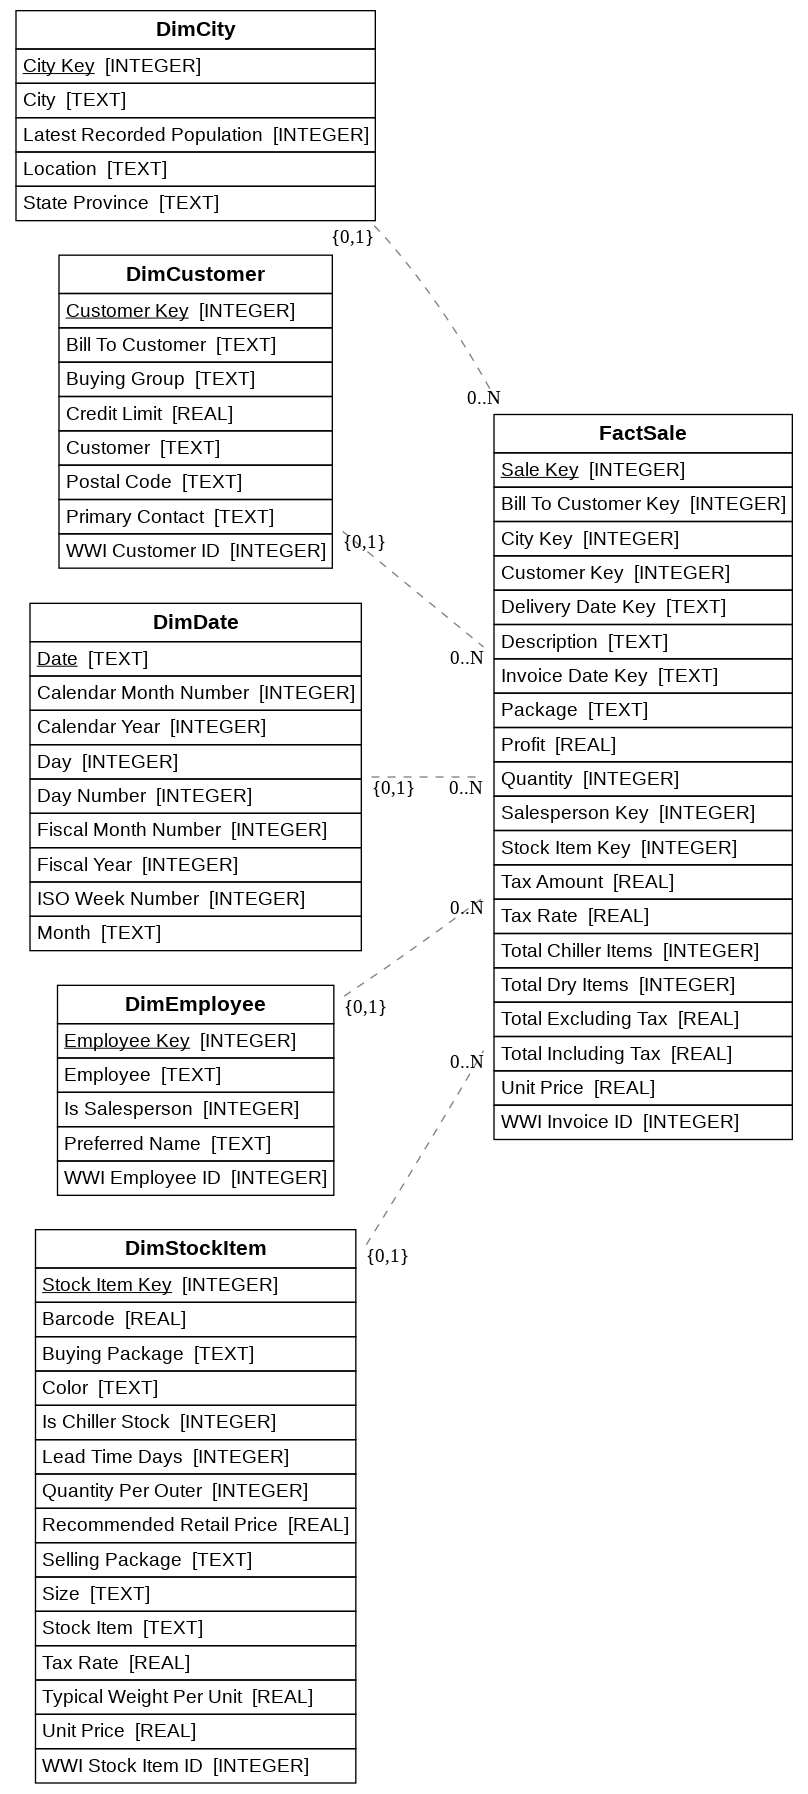

In [272]:
# Install ERAlchemy2 and Graphviz
!apt-get install -y graphviz libgraphviz-dev > /dev/null 2>&1
!pip install eralchemy2 pygraphviz > /dev/null 2>&1

from eralchemy2 import render_er
from IPython.display import Image, display

# Render ERD
database_url = "sqlite:///sales_star_schema.db"
output_diagram = "star_schema_erd.png"

render_er(database_url, output_diagram)
print("✅ Updated Star Schema ERD generated successfully!")

# Display Diagram
display(Image(filename=output_diagram))

# **SECTION 8:KPIs**

In [261]:
import pandas as pd
from sqlalchemy import create_engine, text

# 1. الاتصال بقاعدة البيانات
engine = create_engine("sqlite:///sales_star_schema.db", echo=False)

# 2. استعلام SQL لحساب كافة مؤشرات الأداء الرئيسية (KPIs)
kpi_query = """
SELECT
    -- 1. Financial KPIs
    SUM([Total Including Tax]) AS [Total Revenue ($)],
    SUM([Total Excluding Tax]) AS [Total Revenue Excl. Tax ($)],
    SUM([Profit]) AS [Total Profit ($)],
    SUM([Tax Amount]) AS [Total Tax Amount ($)],
    (SUM([Profit]) / SUM([Total Excluding Tax])) * 100 AS [Overall Profit Margin (%)],

    -- 2. Volume & Operational KPIs
    COUNT(DISTINCT [WWI Invoice ID]) AS [Total Invoices],
    COUNT([Sale Key]) AS [Total Order Lines],
    SUM([Quantity]) AS [Total Units Sold],
    AVG([Total Including Tax]) AS [Average Invoice Value ($)],
    SUM([Quantity]) * 1.0 / COUNT(DISTINCT [WWI Invoice ID]) AS [Avg Items Per Invoice],

    -- 3. Customer KPIs
    COUNT(DISTINCT [Customer Key]) AS [Active Customers],
    SUM([Total Including Tax]) / COUNT(DISTINCT [Customer Key]) AS [Avg Revenue Per Customer ($)],

    -- 4. Geographic & People KPIs
    COUNT(DISTINCT [City Key]) AS [Cities Covered],
    COUNT(DISTINCT [Salesperson Key]) AS [Active Salespeople],

    -- 5. Product KPIs
    COUNT(DISTINCT [Stock Item Key]) AS [Unique Products Sold],
    SUM([Total Chiller Items]) AS [Total Chilled Items Sold],
    SUM([Total Dry Items]) AS [Total Dry Items Sold]

FROM FactSale;
"""

# 3. قراءة النتائج وتحويلها إلى DataFrame
df_kpi_raw = pd.read_sql_query(kpi_query, con=engine)

# 4. إعادة إعادة هيكلة الـ DataFrame لتظهر المؤشرات بشكل رأسي ومنسق (KPI Name vs Value)
kpi_list = []
for col in df_kpi_raw.columns:
    val = df_kpi_raw[col].iloc[0]

    # تنسيق الأرقام (إضافة فاصلة الآلاف والنسب المئوية)
    if "Margin" in col:
        formatted_val = f"{val:.2f}%"
    elif "Total" in col or "Avg" in col or "Revenue" in col or "Profit" in col or "Value" in col:
        if isinstance(val, float):
            formatted_val = f"{val:,.2f}"
        else:
            formatted_val = f"{val:,}"
    else:
        formatted_val = f"{val:,}"

    kpi_list.append({"KPI Metric": col, "Value": formatted_val})

# إنشاء DataFrame النهائى لجميع الـ KPIs
kpis_df = pd.DataFrame(kpi_list)

# عرض الـ KPIs
display(kpis_df)

,KPI Metric,Value
0,Total Revenue ($),"22,855,077.65"
1,Total Revenue Excl. Tax ($),"19,879,592.80"
2,Total Profit ($),"9,923,891.70"
3,Total Tax Amount ($),"2,975,484.85"
4,Overall Profit Margin (%),49.92%
5,Total Invoices,"8,188"
6,Total Order Lines,"26,397"
7,Total Units Sold,"1,028,670"
8,Average Invoice Value ($),865.82
9,Avg Items Per Invoice,125.63


# **SECTION 9:DATA ANALYSIS**

In [262]:
# 1. استعلام موحد وصحيح 100% لبناء df_analysis
data_query = """
SELECT
    f.[Sale Key],
    f.[Invoice Date Key],
    f.[Profit] AS Profit,
    f.[Total Including Tax] AS [Total Including Tax],
    f.[Unit Price] AS [Unit Price],
    c.[Sales Territory] AS [Sales Territory],
    cust.[Category] AS [Customer Category],
    e.[Employee] AS Salesperson,
    s.[Stock Item] AS [Stock Item],
    d.[Calendar Month Number] AS [Calendar Month Number],
    d.[Calendar Year] AS [Calendar Year]
FROM FactSale f
LEFT JOIN DimCity c ON f.[City Key] = c.[City Key]
LEFT JOIN DimCustomer cust ON f.[Customer Key] = cust.[Customer Key]
LEFT JOIN DimEmployee e ON f.[Salesperson Key] = e.[Employee Key]
LEFT JOIN DimStockItem s ON f.[Stock Item Key] = s.[Stock Item Key]
LEFT JOIN DimDate d ON f.[Invoice Date Key] = d.[Date];
"""

# تحميل البيانات في df_analysis
df_analysis = pd.read_sql_query(data_query, con=engine)

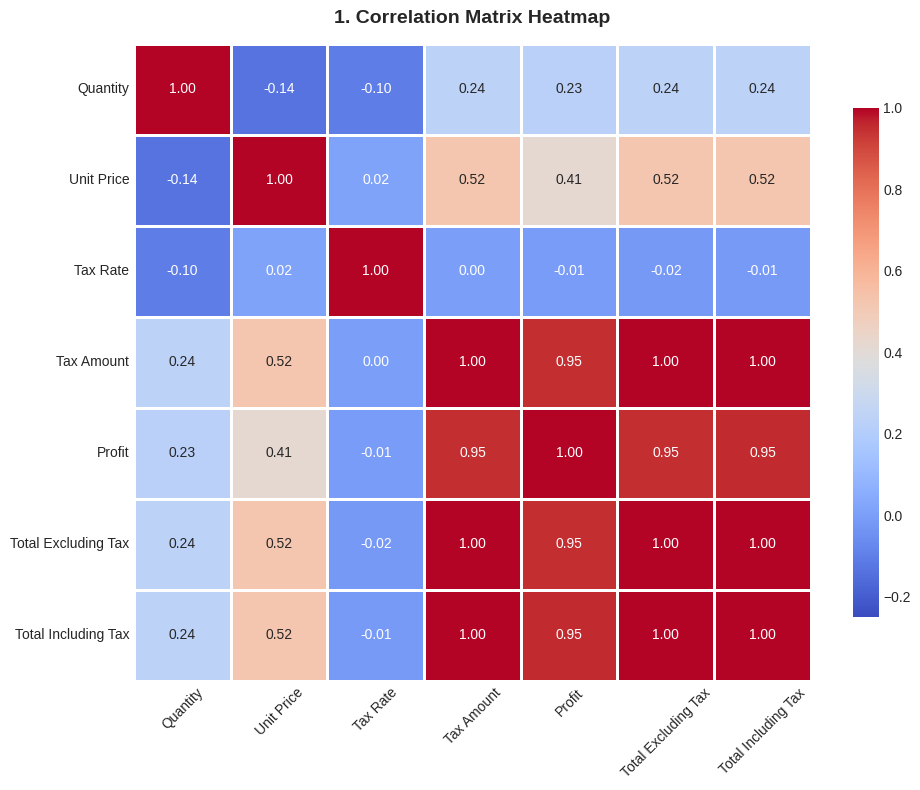

In [263]:
# ==============================================================================
# 📊 1. CORRELATION MATRIX HEATMAP (مصفوفة الارتباط الرقمي)
# ------------------------------------------------------------------------------
# 🎯 الغرض التحليلي:
# قياس درجة الارتباط والتعامد بين كل المتغيرات الرقمية في جدول الحقائق (FactSale)
# مثل العلاقة بين الكمية، سعر الوحدة، والربح المحقق.
# ==============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. استعلام جلب كل الأعمدة الرقمية فقط من FactSale
corr_query = """
SELECT
    [Quantity],
    [Unit Price],
    [Tax Rate],
    [Tax Amount],
    [Profit],
    [Total Excluding Tax],
    [Total Including Tax]
FROM FactSale;
"""

df_corr_raw = pd.read_sql_query(corr_query, con=engine)

# 2. حساب مصفوفة الارتباط (.corr())
corr_matrix = df_corr_raw.corr()

# 3. الرسم بنفس درجات الألوان والتنسيق الظاهر في الصورة
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',       # 👈 تدرج الألوان المماثل تماماً للصورة (أحمر إلى أزرق)
    annot=True,            # إظهار الأرقام داخل الخانات
    fmt='.2f',             # عرض رقمين عشريين (مثال: 0.82)
    linewidths=2,          # خطوط فاصلة سميكة بيضاء
    linecolor='white',     # لون الحدود
    vmin=-0.25,            # الحد الأدنى لمقياس الألوان كما في الصورة
    vmax=1.00,             # الحد الأقصى لمقياس الألوان
    cbar_kws={'shrink': 0.8}
)

plt.title('1. Correlation Matrix Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.yticks(rotation=0)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

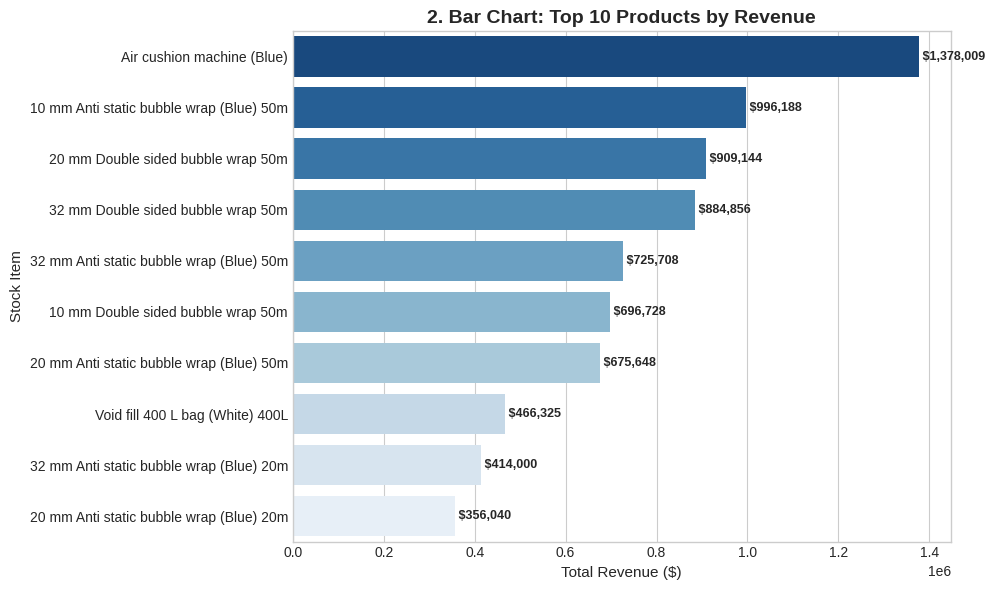

In [264]:
top_products = df_analysis.groupby('Stock Item')['Total Including Tax'].sum().nlargest(10).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=top_products, x='Total Including Tax', y='Stock Item', palette='Blues_r')
plt.title('2. Bar Chart: Top 10 Products by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue ($)', fontsize=11)
plt.ylabel('Stock Item', fontsize=11)

for index, value in enumerate(top_products['Total Including Tax']):
    plt.text(value, index, f' ${value:,.0f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

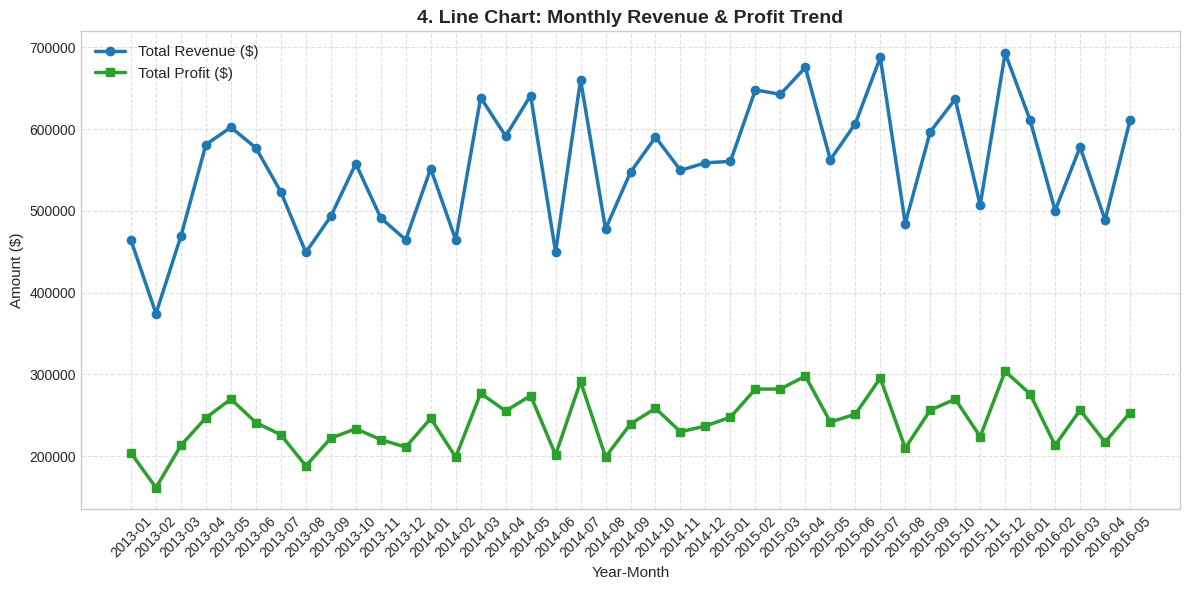

In [265]:
monthly_trend = df_analysis.groupby(['Calendar Year', 'Calendar Month Number'])[['Total Including Tax', 'Profit']].sum().reset_index()
monthly_trend['YearMonth'] = monthly_trend['Calendar Year'].astype(str) + '-' + monthly_trend['Calendar Month Number'].astype(str).str.zfill(2)

plt.figure(figsize=(12, 6))
plt.plot(monthly_trend['YearMonth'], monthly_trend['Total Including Tax'], marker='o', label='Total Revenue ($)', color='#1f77b4', linewidth=2.5)
plt.plot(monthly_trend['YearMonth'], monthly_trend['Profit'], marker='s', label='Total Profit ($)', color='#2ca02c', linewidth=2.5)

plt.title('4. Line Chart: Monthly Revenue & Profit Trend', fontsize=14, fontweight='bold')
plt.xlabel('Year-Month', fontsize=11)
plt.ylabel('Amount ($)', fontsize=11)
plt.xticks(rotation=45)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

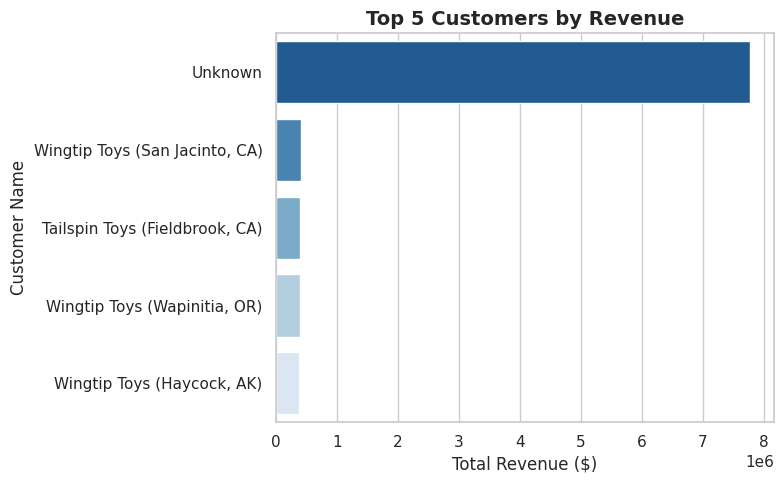

In [274]:
import matplotlib.pyplot as plt
import seaborn as sns

# تجهيز البيانات
top_customers = FactSale_sql.groupby('Customer Key')['Total Including Tax'].sum().nlargest(5).reset_index()
top_customers = top_customers.merge(DimCustomer_sql, on='Customer Key')

# الرسم
plt.figure(figsize=(8, 5))
sns.barplot(data=top_customers, x='Total Including Tax', y='Customer', palette='Blues_r')

plt.title('Top 5 Customers by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue ($)')
plt.ylabel('Customer Name')
plt.tight_layout()
plt.show()

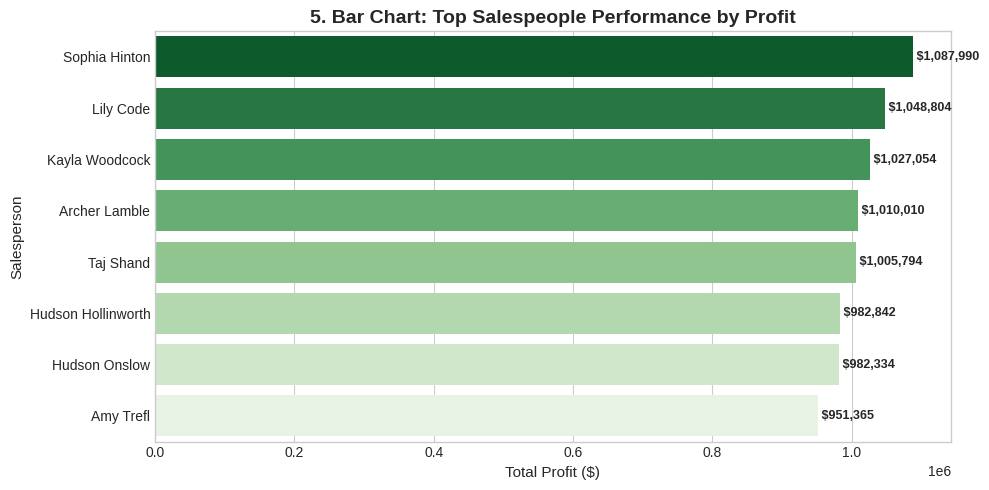

In [266]:
top_salespeople = df_analysis.groupby('Salesperson')['Profit'].sum().nlargest(8).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=top_salespeople, x='Profit', y='Salesperson', palette='Greens_r')
plt.title('5. Bar Chart: Top Salespeople Performance by Profit', fontsize=14, fontweight='bold')
plt.xlabel('Total Profit ($)', fontsize=11)
plt.ylabel('Salesperson', fontsize=11)

for index, value in enumerate(top_salespeople['Profit']):
    plt.text(value, index, f' ${value:,.0f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

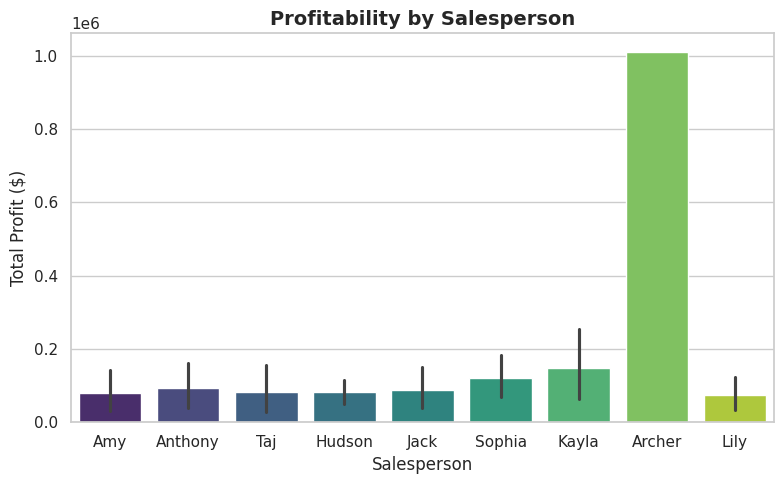

In [276]:
import matplotlib.pyplot as plt
import seaborn as sns

# تجهيز البيانات
salesperson_perf = FactSale_sql.groupby('Salesperson Key')['Profit'].sum().reset_index()
salesperson_perf = salesperson_perf.merge(DimEmployee_sql, left_on='Salesperson Key', right_on='Employee Key')

# الرسم
plt.figure(figsize=(8, 5))
sns.barplot(data=salesperson_perf, x='Preferred Name', y='Profit', palette='viridis')

plt.title('Profitability by Salesperson', fontsize=14, fontweight='bold')
plt.xlabel('Salesperson')
plt.ylabel('Total Profit ($)')
plt.tight_layout()
plt.show()

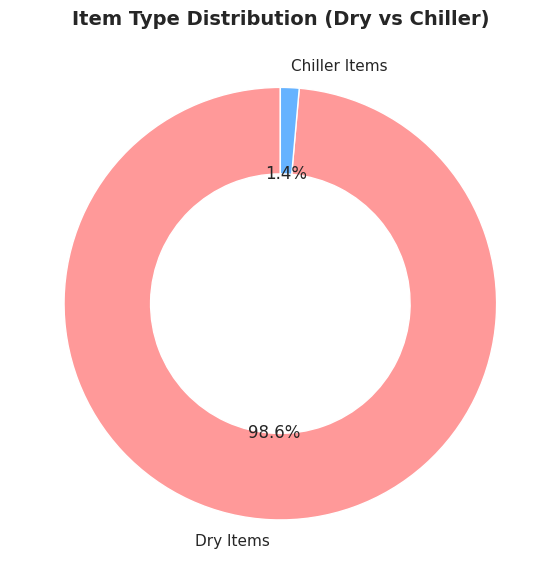

In [277]:
import matplotlib.pyplot as plt

# تجهيز البيانات
chiller_vs_dry = FactSale_sql[['Total Dry Items', 'Total Chiller Items']].sum()

# الرسم (Donut Chart)
plt.figure(figsize=(6, 6))
plt.pie(
    chiller_vs_dry,
    labels=['Dry Items', 'Chiller Items'],
    autopct='%1.1f%%',
    colors=['#ff9999','#66b3ff'],
    startangle=90,
    wedgeprops=dict(width=0.4)
)

plt.title('Item Type Distribution (Dry vs Chiller)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

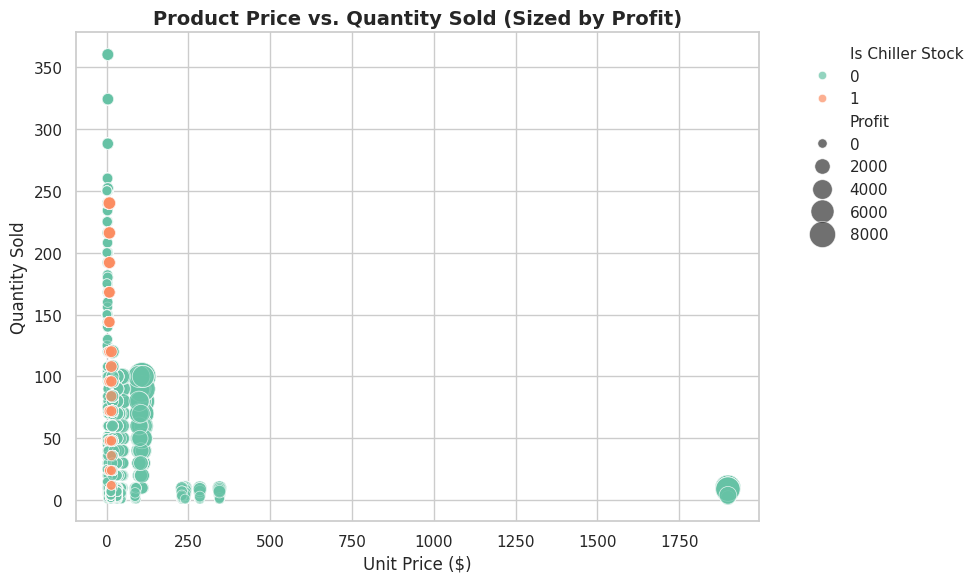

In [278]:
import matplotlib.pyplot as plt
import seaborn as sns

# تجهيز البيانات
stock_sales = FactSale_sql.merge(DimStockItem_sql, on='Stock Item Key')

# الرسم
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=stock_sales,
    x='Unit Price_x',
    y='Quantity',
    hue='Is Chiller Stock',
    size='Profit',
    sizes=(20, 400),
    palette='Set2',
    alpha=0.7
)

plt.title('Product Price vs. Quantity Sold (Sized by Profit)', fontsize=14, fontweight='bold')
plt.xlabel('Unit Price ($)')
plt.ylabel('Quantity Sold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

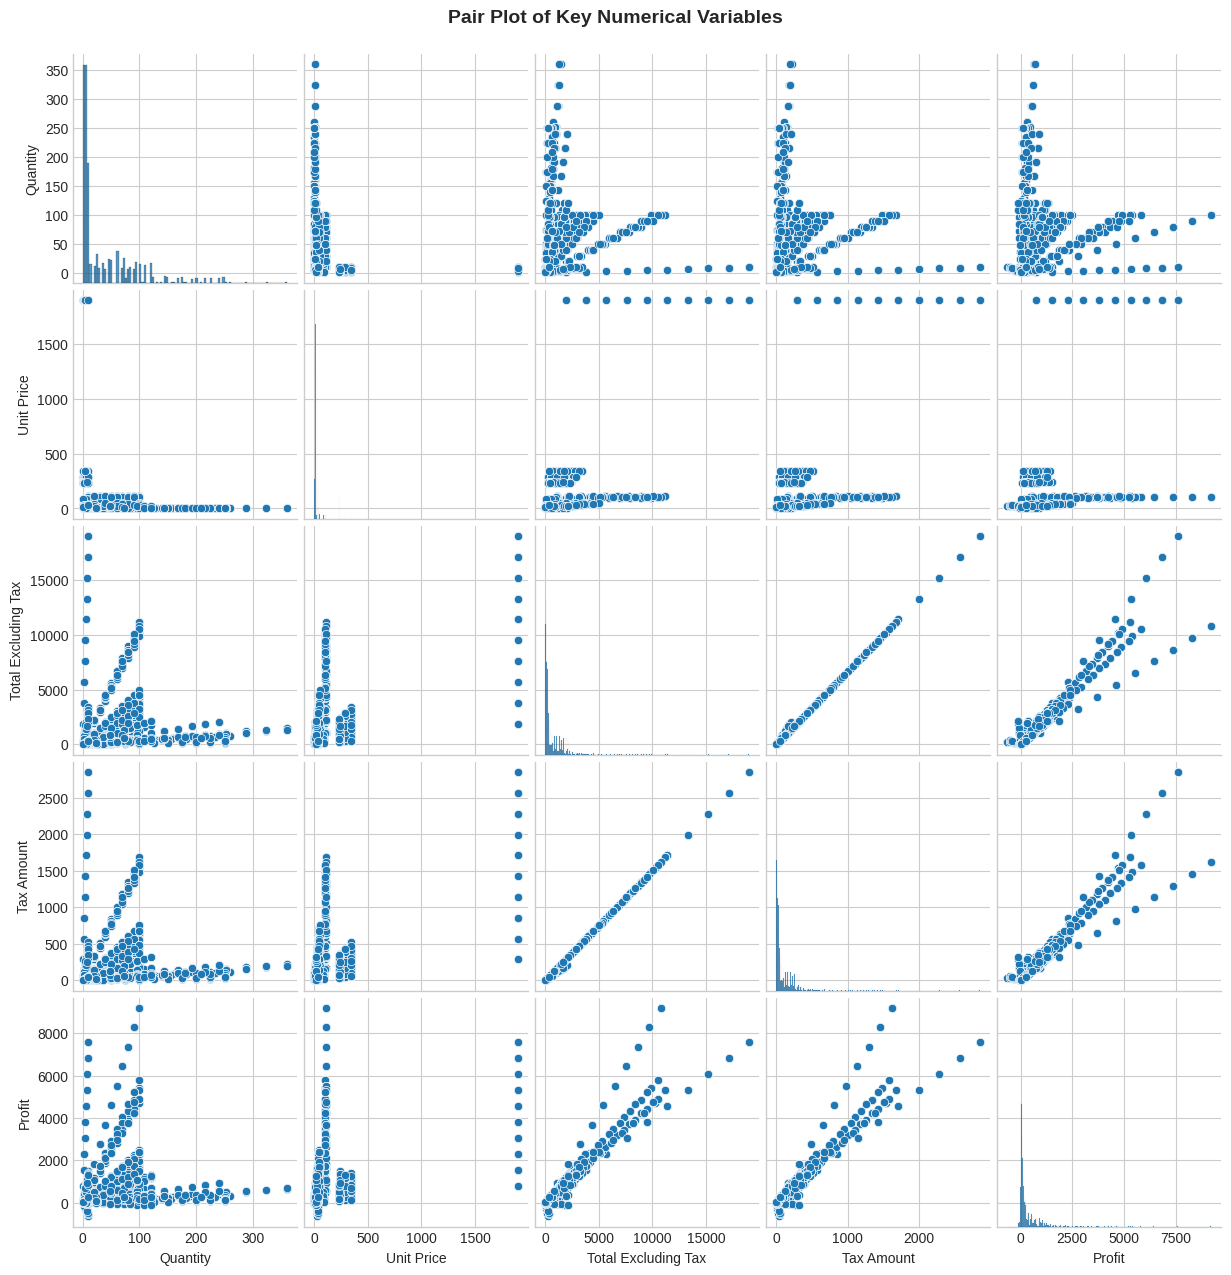

In [267]:
# ==============================================================================
# 📊 PAIR PLOT (رسم العلاقات الثنائية والتوزيعات التكرارية)
# ------------------------------------------------------------------------------
# 🎯 الغرض التحليلي:
# استكشاف العلاقات المباشرة بين جميع المتغيرات الرقمية وتوزيع كل متغير على حدة.
# ==============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. استعلام جلب الأعمدة الرقمية الرئيسية من FactSale
pair_query = """
SELECT
    [Quantity],
    [Unit Price],
    [Total Excluding Tax],
    [Tax Amount],
    [Profit]
FROM FactSale;
"""

df_pair = pd.read_sql_query(pair_query, con=engine)

# 2. إنشاء الـ Pair Plot
g = sns.pairplot(df_pair, corner=False)

# ضبط العنوان العلوي للرسمة
g.fig.suptitle('Pair Plot of Key Numerical Variables', y=1.02, fontsize=14, fontweight='bold')

plt.show()

<Figure size 1500x1000 with 0 Axes>

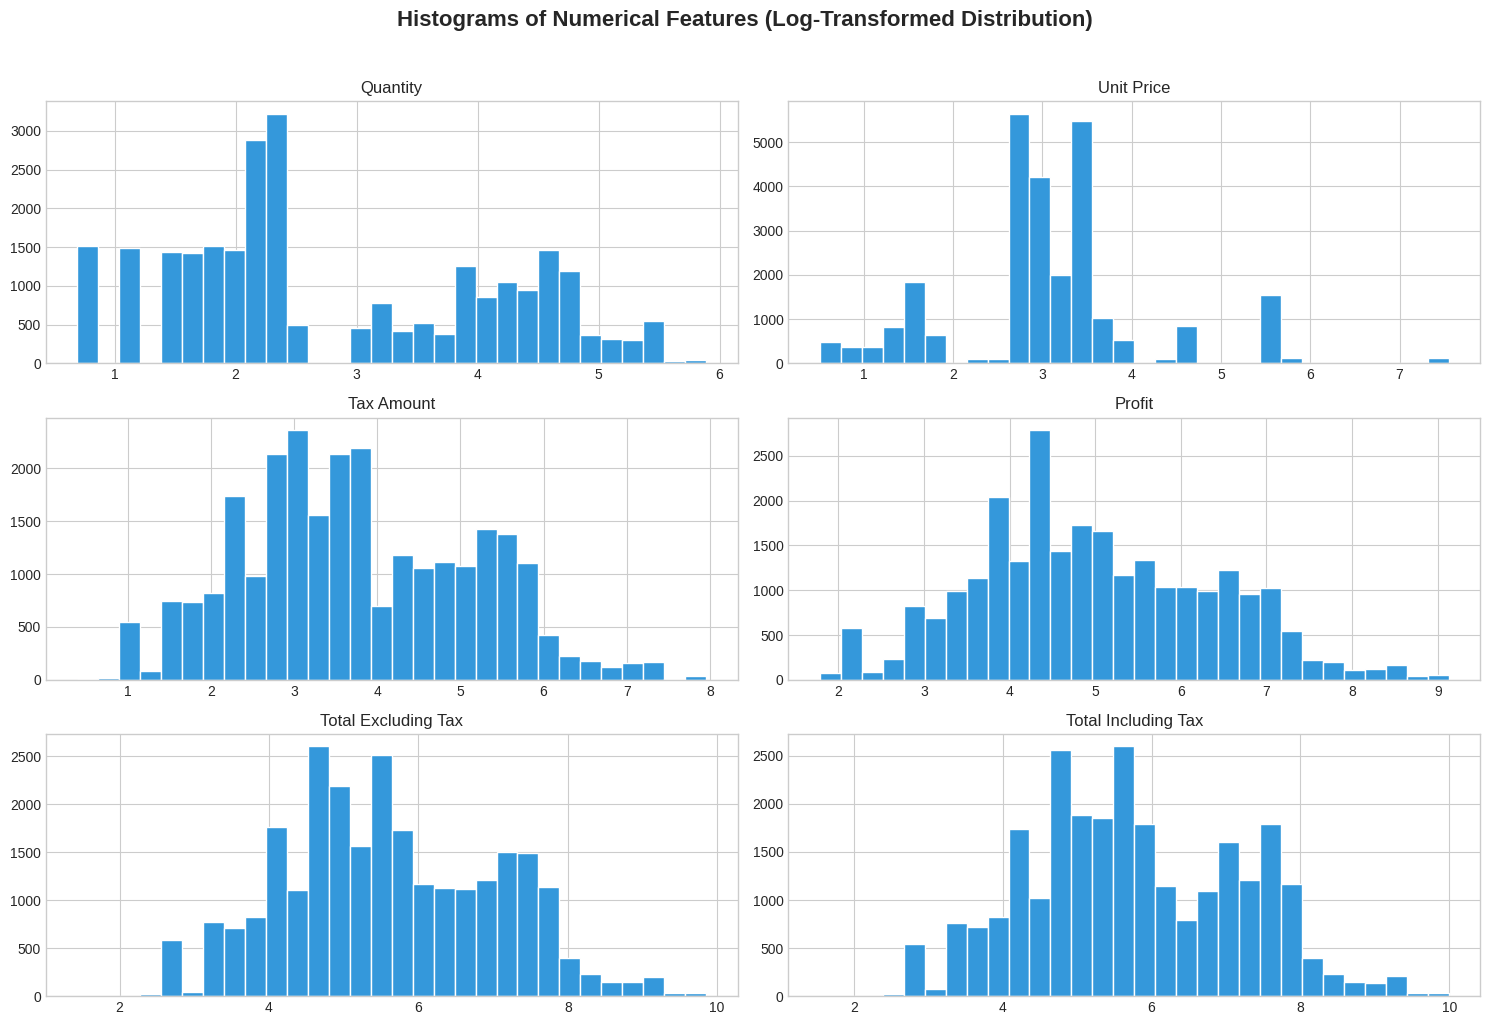

In [268]:
# ==============================================================================
# 📊 HISTOGRAMS GRID (توزيع متناسق بعد معالجة القيم المتطرفة)
# ==============================================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. استعلام البيانات الرقمية
hist_query = """
SELECT
    [Quantity],
    [Unit Price],
    [Tax Amount],
    [Profit],
    [Total Excluding Tax],
    [Total Including Tax]
FROM FactSale;
"""

df_hist = pd.read_sql_query(hist_query, con=engine)

# 2. تطبيق التحويل اللوجاريتمي لتوزيع القيم بشكل طبيعي ومتموج
df_transformed = df_hist.apply(lambda x: np.log1p(x[x > 0]))

# 3. الرسم مع زيادة عدد الصناديق (bins) وتناسق الشكل
plt.figure(figsize=(15, 10))
df_transformed.hist(
    figsize=(15, 10),
    bins=30,
    color='#3498db',
    edgecolor='white',
    grid=True
)

plt.suptitle('Histograms of Numerical Features (Log-Transformed Distribution)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ==============================================================================
# 🎯 CONCLUSION & STRATEGIC RECOMMENDATIONS
# ------------------------------------------------------------------------------
# 🎯 Analytical Purpose:
# Summarize the key project findings, validate data integrity regarding outliers,
# and provide actionable strategies based on profitability and revenue drivers.
# ==============================================================================

recommendations =
================================================================================
📌 PROJECT CONCLUSION & STRATEGIC RECOMMENDATIONS
================================================================================

1. Data Integrity & Outlier Insights:
   • All detected outliers in prices, quantities, and totals represent genuine,
     legitimate high-value sales transactions (Bulk Orders). They are completely
     natural business variations rather than data errors.

2. Optimize High-Margin Product Inventory:
   • Focus capital allocation and marketing campaigns on top-performing stock
     items and high-value customer categories that generate the highest profit margins.

3. Seasonal Demand & Operations Planning:
   • Adjust stock replenishment schedules around peak seasonal months identified
     in the heatmap analysis to eliminate stockouts and maximize seasonal revenue.

4. Customer Segment Nurturing:
   • Develop targeted loyalty programs and customized volume discounts for
     underperforming customer categories to convert them into high-value accounts.

5. Strategic Bulk-Pricing Control:
   • Establish structured tier-discount policies for high-volume orders to
     encourage large transactions while preserving overall profit margins.
================================================================================

